In [1]:
import pandas as pd
import os
import seaborn as sns

In [2]:
data_dir = "/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/metrics_new"

In [61]:
dfs = []
for el in os.listdir(data_dir):
    if el.endswith("metrics.csv"):
        dfs.append(pd.read_csv(os.path.join(data_dir, el), index_col=0))

In [62]:
len(dfs)

2625

In [63]:
df = pd.concat([el.T for el in dfs])

In [64]:
for el in df.columns:
    try:
        df[el] = df[el].astype("float")
    except:
        continue

In [65]:
df["donor_cytokine"] = df.index
df["donor"] = df.apply(lambda x: x["donor_cytokine"].split("_")[0], axis=1)
df["cytokine"] = df.apply(lambda x: x["donor_cytokine"].split("_")[1], axis=1)

/tmp/ipykernel_3919075/2027898116.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["donor_cytokine"] = df.index
/tmp/ipykernel_3919075/2027898116.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["donor"] = df.apply(lambda x: x["donor_cytokine"].split("_")[0], axis=1)
/tmp/ipykernel_3919075/2027898116.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instea

compare with old

In [66]:
df_old = pd.read_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/metrics/metrics_new_cytokine.csv", index_col=0)

In [67]:
df_old.head()

,mean_decoded_r_sq_per_cell_type,mean_e_distance_per_cell_type,mean_mmd_per_cell_type,mean_sdiv_10_per_cell_type,mean_sdiv_100_per_cell_type,mean_deg_r_sq_per_cell_type,mean_deg_e_distance_per_cell_type,mean_deg_mmd_per_cell_type,mean_deg_sdiv_10_per_cell_type,mean_deg_sdiv_100_per_cell_type,...,div_10_pDC,div_100_pDC,deg_decoded_r_squared_pDC,deg_e_distance_pDC,deg_mmd_pDC,deg_div_10_pDC,deg_div_100_pDC,donor_cytokine,donor,cytokine
Donor4_C5a,0.955791,11.660839,0.008871,90.671855,12.128944,0.873296,17.662023,0.040608,125.486287,17.470218,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Donor4_C5a,Donor4,C5a
Donor7_OX40L,0.922924,35.460599,0.013862,111.972876,25.847652,0.765109,35.802167,0.046710,147.587429,29.255601,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Donor7_OX40L,Donor7,OX40L
Donor10_C5a,0.948272,16.919249,0.010235,97.359693,15.502340,0.816124,25.159851,0.041936,139.200932,21.871986,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Donor10_C5a,Donor10,C5a
Donor11_4-1BBL,0.931346,22.054480,0.014290,102.952084,17.665734,0.813616,24.228663,0.046342,151.745742,23.805972,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Donor11_4-1BBL,Donor11,4-1BBL
Donor6_OSM,0.955859,13.854135,0.007579,96.074269,13.403070,0.880971,18.501366,0.038873,129.942240,16.470612,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Donor6_OSM,Donor6,OSM


In [68]:
df_old.shape

(2628, 172)

In [69]:
import seaborn as sns

<Axes: xlabel='num_donors_in_train', ylabel='ood_e_distance'>

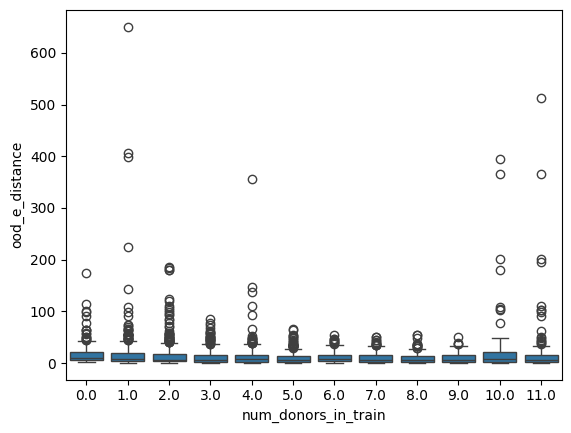

In [70]:
sns.boxplot(df, x="num_donors_in_train", y="ood_e_distance")

In [71]:
df_ifn_eps = df[df["cytokine"]=="IFN-epsilon"]
df_old_ifn_eps = df_old[df_old["cytokine"]=="IFN-epsilon"]

<Axes: xlabel='num_donors_in_train', ylabel='decoded_ood_r_squared'>

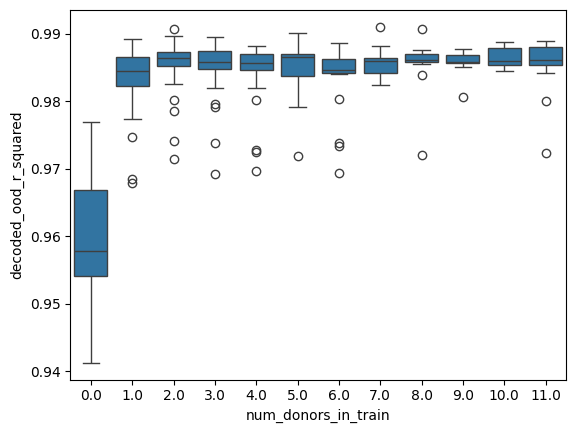

In [72]:
sns.boxplot(df_ifn_eps, x="num_donors_in_train", y="decoded_ood_r_squared")

In [80]:
df_old[df_old["num_donors_in_train"]==0]["ood_e_distance"].mean()

37.905033929583276

In [81]:
df[df["num_donors_in_train"]==0]["ood_e_distance"].mean()

19.228230304510937

In [82]:
df["type"] = "new"
df_old["type"] = "old"
dff = pd.concat((df, df_old))

/tmp/ipykernel_3919075/628444761.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["type"] = "new"


<Axes: xlabel='num_donors_in_train', ylabel='ood_e_distance'>

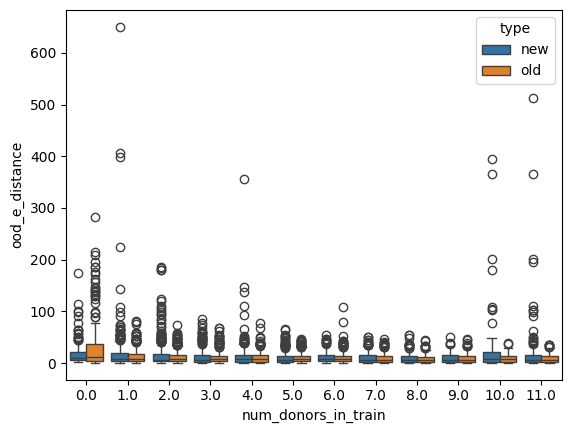

In [84]:
sns.boxplot(dff, x="num_donors_in_train", y="ood_e_distance", hue="type")

In [88]:
dff[dff["num_donors_in_train"]<10].groupby("type")["ood_e_distance"].mean()

type
new    13.898662
old    12.823604
Name: ood_e_distance, dtype: float64

In [78]:
df_old["cytokine"].value_counts()

cytokine
C5a            219
OX40L          219
4-1BBL         219
OSM            219
Noggin         219
IFN-beta       219
IFN-epsilon    219
IL-15          219
ADSF           219
IL-13          219
APRIL          219
BAFF           219
Name: count, dtype: int64

In [79]:
df["cytokine"].value_counts()

cytokine
4-1BBL         220
IL-13          219
C5a            219
ADSF           219
OX40L          219
OSM            219
Noggin         219
IFN-beta       219
APRIL          219
BAFF           219
IFN-epsilon    218
IL-15          216
Name: count, dtype: int64

In [21]:
import numpy as np
df["ood_distance_appr"] = df.apply(lambda x: np.round(x["ood_e_distance"],5), axis=1)

/tmp/ipykernel_3919075/4215064738.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ood_distance_appr"] = df.apply(lambda x: np.round(x["ood_e_distance"],5), axis=1)


In [22]:
df.drop_duplicates("ood_distance_appr")["cytokine"].value_counts()

cytokine
IFN-epsilon    228
IL-15          225
4-1BBL         220
IL-13          219
C5a            219
ADSF           219
OX40L          219
OSM            219
Noggin         219
IFN-beta       219
BAFF           219
APRIL          208
Name: count, dtype: int64

In [54]:
df[df["cytokine"]=="IL-15"]["num_donors_in_train"].value_counts()

num_donors_in_train
2.0     40
3.0     27
4.0     24
1.0     22
5.0     21
6.0     18
11.0    16
7.0     15
0.0     12
8.0     12
10.0    10
9.0      9
Name: count, dtype: int64

In [58]:
df[(df["cytokine"]=="IL-15") & (df["num_donors_in_train"]==2)]#["wandb_name"].value_counts()#.drop_duplicates("donors_in_train")

,mean_decoded_r_sq_per_cell_type,mean_e_distance_per_cell_type,mean_mmd_per_cell_type,mean_sdiv_10_per_cell_type,mean_sdiv_100_per_cell_type,mean_deg_r_sq_per_cell_type,mean_deg_e_distance_per_cell_type,mean_deg_mmd_per_cell_type,mean_deg_sdiv_10_per_cell_type,mean_deg_sdiv_100_per_cell_type,...,ood_mmd,ood_sdiv_10,ood_sdiv_100,predicted_deg_genes,wandb_name,donors_in_train,num_donors_in_train,donor_cytokine,donor,cytokine
Donor9_IL-15,0.858799,80.040098,0.031239,NaN,NaN,0.370837,97.968350,0.058641,NaN,NaN,...,0.004078,NaN,NaN,"['HBA1', 'ENSG00000290421', 'LINC00326', 'ENSG...",soft-glade-529,"['Donor4', 'Donor5']",2.0,Donor9_IL-15,Donor9,IL-15
Donor5_IL-15,0.816384,171.715407,0.058360,NaN,NaN,-0.101614,192.840703,0.098474,NaN,NaN,...,0.012641,NaN,NaN,"['LINC00326', 'HBA2', 'ENSG00000290421', 'ENSG...",laced-shadow-486,['Donor1' 'Donor4'],2.0,Donor5_IL-15,Donor5,IL-15
Donor9_IL-15,0.832302,114.781521,0.040664,NaN,NaN,0.312007,104.360707,0.055243,NaN,NaN,...,0.010193,NaN,NaN,"['ENSG00000289578', 'HBA1', 'LINC00326', 'ENSG...",soft-glade-529,"['Donor4', 'Donor5']",2.0,Donor9_IL-15,Donor9,IL-15
Donor9_IL-15,0.832587,116.738709,0.041237,NaN,NaN,0.239759,118.181978,0.062232,NaN,NaN,...,0.008219,NaN,NaN,"['NPHS1', 'HBA2', 'HBB', 'ENSG00000229066', 'H...",rural-aardvark-528,"['Donor1', 'Donor4']",2.0,Donor9_IL-15,Donor9,IL-15
Donor9_IL-15,0.849342,89.152691,0.033279,NaN,NaN,0.305093,108.117276,0.060350,NaN,NaN,...,0.004787,NaN,NaN,"['HBA1', 'ENSG00000289578', 'ENSG00000290421',...",rural-aardvark-528,"['Donor1', 'Donor4']",2.0,Donor9_IL-15,Donor9,IL-15
Donor9_IL-15,0.756413,213.700312,0.066950,NaN,NaN,-0.009101,152.139830,0.071259,NaN,NaN,...,0.016177,NaN,NaN,"['HBA1', 'ENSG00000290421', 'HBA2', 'HBB', 'EN...",deep-bird-529,"['Donor4', 'Donor7']",2.0,Donor9_IL-15,Donor9,IL-15
Donor9_IL-15,0.864404,75.417730,0.029082,NaN,NaN,0.462700,82.794321,0.049038,NaN,NaN,...,0.005048,NaN,NaN,"['HBA1', 'LINC00326', 'ENSG00000290421', 'HBA2...",deep-bird-529,"['Donor4', 'Donor7']",2.0,Donor9_IL-15,Donor9,IL-15
Donor9_IL-15,0.852635,88.422048,0.033443,NaN,NaN,0.327897,105.069306,0.060465,NaN,NaN,...,0.004743,NaN,NaN,"['HBA1', 'ENSG00000290421', 'ENSG00000289578',...",deep-bird-529,"['Donor4', 'Donor7']",2.0,Donor9_IL-15,Donor9,IL-15
Donor9_IL-15,0.814664,140.417132,0.044862,NaN,NaN,0.220121,122.412960,0.062105,NaN,NaN,...,0.008213,NaN,NaN,"['HBA1', 'HBA2', 'HBB', 'LINC00326', 'ENSG0000...",soft-glade-529,"['Donor4', 'Donor5']",2.0,Donor9_IL-15,Donor9,IL-15
Donor9_IL-15,0.808378,149.047450,0.047007,NaN,NaN,0.176836,129.476694,0.064226,NaN,NaN,...,0.008903,NaN,NaN,"['HBA1', 'HBA2', 'HBB', 'LINC00326', 'ENSG0000...",deep-bird-529,"['Donor4', 'Donor7']",2.0,Donor9_IL-15,Donor9,IL-15


In [30]:
df_red = df[df["wandb_name"]!="driven-eon-544"]

In [34]:
list(df.columns)

['mean_decoded_r_sq_per_cell_type',
 'mean_e_distance_per_cell_type',
 'mean_mmd_per_cell_type',
 'mean_sdiv_10_per_cell_type',
 'mean_sdiv_100_per_cell_type',
 'mean_deg_r_sq_per_cell_type',
 'mean_deg_e_distance_per_cell_type',
 'mean_deg_mmd_per_cell_type',
 'mean_deg_sdiv_10_per_cell_type',
 'mean_deg_sdiv_100_per_cell_type',
 'decoded_r_squared_CD8 Naive',
 'decoded_r_squared_B Naive',
 'decoded_r_squared_B Intermediate/Memory',
 'decoded_r_squared_CD14 Mono',
 'decoded_r_squared_CD4 Naive',
 'decoded_r_squared_CD56-dim NK',
 'decoded_r_squared_CD4 Memory',
 'decoded_r_squared_cDC',
 'decoded_r_squared_CD8 Memory',
 'decoded_r_squared_CD16 Mono',
 'decoded_r_squared_CD56-bright NK',
 'decoded_r_squared_MAIT',
 'decoded_r_squared_Treg',
 'decoded_r_squared_NKT',
 'decoded_r_squared_pDC',
 'e_distance_CD8 Naive',
 'e_distance_B Naive',
 'e_distance_B Intermediate/Memory',
 'e_distance_CD14 Mono',
 'e_distance_CD4 Naive',
 'e_distance_CD56-dim NK',
 'e_distance_CD4 Memory',
 'e_dista

In [60]:
import os

# directory you want to clean
directory = data_dir

# target substring
substring = "soft-glade-529"

for filename in os.listdir(directory):
    if substring in filename:
        file_path = os.path.join(directory, filename)
        if os.path.isfile(file_path):
            os.remove(file_path)
            print(f"Deleted: {file_path}")


Deleted: /lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/metrics_new/soft-glade-529_Donor8_IL-15_2_2_metrics.csv
Deleted: /lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/metrics_new/soft-glade-529_Donor10_IL-15_2_2_metrics.csv
Deleted: /lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/metrics_new/soft-glade-529_Donor12_IL-15_2_2_metrics.csv
Deleted: /lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/metrics_new/soft-glade-529_Donor9_IL-15_2_2_metrics.csv
Deleted: /lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/metrics_new/soft-glade-529_Donor3_IL-15_2_2_metrics.csv
Deleted: /lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/metrics_new/soft-glade-529_Donor6_IL-15_2_2_metrics.csv
Deleted: /lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/metrics_new/soft-glade-529_Donor11_IL-15_2_2_metrics.csv
Deleted: /lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/metrics_new/soft-glade-529_Donor2_IL-15_2_2_metrics.csv
Deleted: /lustre/groups/ml01/

In [59]:
df[df["wandb_name"]=="soft-glade-529"]

,mean_decoded_r_sq_per_cell_type,mean_e_distance_per_cell_type,mean_mmd_per_cell_type,mean_sdiv_10_per_cell_type,mean_sdiv_100_per_cell_type,mean_deg_r_sq_per_cell_type,mean_deg_e_distance_per_cell_type,mean_deg_mmd_per_cell_type,mean_deg_sdiv_10_per_cell_type,mean_deg_sdiv_100_per_cell_type,...,ood_mmd,ood_sdiv_10,ood_sdiv_100,predicted_deg_genes,wandb_name,donors_in_train,num_donors_in_train,donor_cytokine,donor,cytokine
Donor9_IL-15,0.858799,80.040098,0.031239,NaN,NaN,0.370837,97.968350,0.058641,NaN,NaN,...,0.004078,NaN,NaN,"['HBA1', 'ENSG00000290421', 'LINC00326', 'ENSG...",soft-glade-529,"['Donor4', 'Donor5']",2.0,Donor9_IL-15,Donor9,IL-15
Donor9_IL-15,0.832302,114.781521,0.040664,NaN,NaN,0.312007,104.360707,0.055243,NaN,NaN,...,0.010193,NaN,NaN,"['ENSG00000289578', 'HBA1', 'LINC00326', 'ENSG...",soft-glade-529,"['Donor4', 'Donor5']",2.0,Donor9_IL-15,Donor9,IL-15
Donor9_IL-15,0.814664,140.417132,0.044862,NaN,NaN,0.220121,122.412960,0.062105,NaN,NaN,...,0.008213,NaN,NaN,"['HBA1', 'HBA2', 'HBB', 'LINC00326', 'ENSG0000...",soft-glade-529,"['Donor4', 'Donor5']",2.0,Donor9_IL-15,Donor9,IL-15
Donor9_IL-15,0.869893,87.123148,0.035335,NaN,NaN,0.313675,111.317665,0.068656,NaN,NaN,...,0.005353,NaN,NaN,"['HBA1', 'ENSG00000290421', 'HBA2', 'HBB', 'EN...",soft-glade-529,"['Donor4', 'Donor5']",2.0,Donor9_IL-15,Donor9,IL-15
Donor9_IL-15,0.753649,214.072063,0.067507,NaN,NaN,-0.024617,154.250927,0.072077,NaN,NaN,...,0.016155,NaN,NaN,"['HBA1', 'ENSG00000290421', 'LINC00326', 'HBA2...",soft-glade-529,"['Donor4', 'Donor5']",2.0,Donor9_IL-15,Donor9,IL-15
Donor9_IL-15,0.863726,75.917665,0.029186,NaN,NaN,0.458769,83.082706,0.049332,NaN,NaN,...,0.005240,NaN,NaN,"['HBA1', 'ENSG00000289578', 'LINC00326', 'ENSG...",soft-glade-529,"['Donor4', 'Donor5']",2.0,Donor9_IL-15,Donor9,IL-15
Donor9_IL-15,0.842883,104.039750,0.038402,NaN,NaN,0.306378,107.537790,0.060386,NaN,NaN,...,0.007194,NaN,NaN,"['HBA1', 'NPHS1', 'HBA2', 'ENSG00000229066', '...",soft-glade-529,"['Donor4', 'Donor5']",2.0,Donor9_IL-15,Donor9,IL-15
Donor9_IL-15,0.798561,190.037211,0.052622,NaN,NaN,0.247718,120.419638,0.069080,NaN,NaN,...,0.009679,NaN,NaN,"['HBA1', 'LINC00326', 'HBA2', 'ENSG00000229066...",soft-glade-529,"['Donor4', 'Donor5']",2.0,Donor9_IL-15,Donor9,IL-15
Donor9_IL-15,0.823709,120.336532,0.038732,NaN,NaN,0.353313,97.872649,0.054128,NaN,NaN,...,0.009353,NaN,NaN,"['ENSG00000289578', 'HBA1', 'HBA2', 'HBB', 'EN...",soft-glade-529,"['Donor4', 'Donor5']",2.0,Donor9_IL-15,Donor9,IL-15
Donor9_IL-15,0.849422,103.385092,0.040304,NaN,NaN,0.360237,101.768909,0.066878,NaN,NaN,...,0.009682,NaN,NaN,"['ENSG00000289578', 'HBA1', 'LINC00326', 'NPHS...",soft-glade-529,"['Donor4', 'Donor5']",2.0,Donor9_IL-15,Donor9,IL-15


In [33]:
df[df["wandb_name"]=="driven-eon-544"]

,mean_decoded_r_sq_per_cell_type,mean_e_distance_per_cell_type,mean_mmd_per_cell_type,mean_sdiv_10_per_cell_type,mean_sdiv_100_per_cell_type,mean_deg_r_sq_per_cell_type,mean_deg_e_distance_per_cell_type,mean_deg_mmd_per_cell_type,mean_deg_sdiv_10_per_cell_type,mean_deg_sdiv_100_per_cell_type,...,ood_sdiv_10,ood_sdiv_100,predicted_deg_genes,wandb_name,donors_in_train,num_donors_in_train,donor_cytokine,donor,cytokine,ood_distance_appr
Donor9_IFN-epsilon,0.603791,414.226574,0.099551,NaN,NaN,0.194474,135.101049,0.100236,NaN,NaN,...,NaN,NaN,"['HBA1', 'ENSG00000289509', 'LINC00326', 'ENSG...",driven-eon-544,"['Donor10', 'Donor9']",2.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon,371.24595
Donor9_IFN-epsilon,0.892205,57.308393,0.025142,NaN,NaN,0.787448,35.860502,0.054866,NaN,NaN,...,NaN,NaN,"['ENSG00000289578', 'HBA1', 'ENSG00000290421',...",driven-eon-544,"['Donor10', 'Donor9']",2.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon,33.11530
Donor9_IFN-epsilon,0.825931,174.930998,0.046277,NaN,NaN,0.646402,61.816806,0.068249,NaN,NaN,...,NaN,NaN,"['HBA1', 'HBA2', 'HBB', 'NPHS1', 'LINC00326', ...",driven-eon-544,"['Donor10', 'Donor9']",2.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon,108.20418
Donor9_IFN-epsilon,0.754928,215.647955,0.062352,NaN,NaN,0.503113,83.544789,0.076275,NaN,NaN,...,NaN,NaN,"['HBA1', 'ENSG00000290421', 'ENSG00000289578',...",driven-eon-544,"['Donor10', 'Donor9']",2.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon,208.53640
Donor9_IFN-epsilon,0.848286,102.892828,0.036496,NaN,NaN,0.677705,54.203858,0.058777,NaN,NaN,...,NaN,NaN,"['HBA2', 'HBB', 'LINC00326', 'NPHS1', 'ENSG000...",driven-eon-544,"['Donor10', 'Donor9']",2.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon,82.23104
Donor9_IFN-epsilon,0.881697,66.074220,0.028964,NaN,NaN,0.752323,41.467022,0.059791,NaN,NaN,...,NaN,NaN,"['ENSG00000290421', 'LINC00326', 'ENSG00000229...",driven-eon-544,"['Donor10', 'Donor9']",2.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon,127.71644
Donor9_IFN-epsilon,0.879792,69.886055,0.029598,NaN,NaN,0.766786,39.370286,0.055068,NaN,NaN,...,NaN,NaN,"['HBA2', 'ENSG00000229066', 'NPHS1', 'LINC0035...",driven-eon-544,"['Donor10', 'Donor9']",2.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon,107.78398
Donor9_IFN-epsilon,0.752402,227.640584,0.068808,NaN,NaN,0.489662,86.331547,0.080149,NaN,NaN,...,NaN,NaN,"['LINC00326', 'HBA1', 'ENSG00000290421', 'HBA2...",driven-eon-544,"['Donor10', 'Donor9']",2.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon,555.73308
Donor9_IFN-epsilon,0.854760,106.035250,0.038953,NaN,NaN,0.700528,51.034184,0.060895,NaN,NaN,...,NaN,NaN,"['ENSG00000290421', 'HBA1', 'LINC00326', 'HBA2...",driven-eon-544,"['Donor10', 'Donor9']",2.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon,88.81835
Donor9_IFN-epsilon,0.890156,62.734352,0.032645,NaN,NaN,0.783629,37.657396,0.062024,NaN,NaN,...,NaN,NaN,"['LINC00326', 'NPHS1', 'HBA2', 'HBB', 'ENSG000...",driven-eon-544,"['Donor10', 'Donor9']",2.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon,129.97815


In [31]:
df_red[df_red["cytokine"]=="IFN-epsilon"]["num_donors_in_train"].value_counts()

num_donors_in_train
1.0     33
2.0     29
3.0     27
4.0     24
5.0     21
6.0     18
7.0     15
11.0    12
0.0     12
8.0     12
9.0      9
10.0     6
Name: count, dtype: int64

In [25]:
df_old[df_old["cytokine"]=="IFN-epsilon"]["num_donors_in_train"].value_counts()

num_donors_in_train
1.0     33
2.0     30
3.0     27
4.0     24
5.0     21
6.0     18
7.0     15
8.0     12
0.0     12
11.0    12
9.0      9
10.0     6
Name: count, dtype: int64

In [313]:
df[df["cytokine"]=="BAFF"]["donor"].value_counts()

donor
Donor12    22
Donor11    20
Donor9     19
Donor4     19
Donor2     18
Donor5     18
Donor7     17
Donor10    17
Donor3     16
Donor1     14
Donor8     14
Donor6     14
Name: count, dtype: int64

In [314]:
df_old[df_old["cytokine"]=="BAFF"]["donor"].value_counts() - df[df["cytokine"]=="BAFF"]["donor"].value_counts()

donor
Donor1     1
Donor10    1
Donor11    1
Donor12    1
Donor2     1
Donor3     1
Donor4     1
Donor5     0
Donor6     1
Donor7     1
Donor8     1
Donor9     1
Name: count, dtype: int64

In [ ]:
# Donor to train: 11, 3, 5, 9



In [315]:
adata_rest2 = sc.read_h5ad(f"/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/new_cytokine/adata_rest_BAFF.h5ad")


In [317]:
adata_rest2.uns["split_info"]["2"] # 41, 37,35 

{'donors_to_impute': array(['Donor9', 'Donor3', 'Donor6', 'Donor10', 'Donor2', 'Donor1',
        'Donor4', 'Donor12', 'Donor8', 'Donor7', 'Donor11'], dtype=object),
 'donors_to_train_data': array(['Donor5'], dtype=object)}

In [253]:
adata_rest.uns["split_info"]["5"] # 4 or 6

{'donors_to_impute': array(['Donor8', 'Donor10', 'Donor2', 'Donor9', 'Donor7', 'Donor3',
        'Donor1', 'Donor5', 'Donor11', 'Donor12'], dtype=object),
 'donors_to_train_data': array(['Donor4', 'Donor6'], dtype=object)}

In [293]:
df[(df["cytokine"]=="IL-13") & (df["num_donors_in_train"]==11)]["donors_in_train"].value_counts()

donors_in_train
['Donor11' 'Donor12' 'Donor1' 'Donor2' 'Donor3' 'Donor4' 'Donor5' 'Donor6'\n 'Donor7' 'Donor8' 'Donor9']             1
['Donor10' 'Donor11' 'Donor12' 'Donor1' 'Donor2' 'Donor3' 'Donor4'\n 'Donor5' 'Donor7' 'Donor8' 'Donor9']            1
['Donor10' 'Donor11' 'Donor1' 'Donor2' 'Donor3' 'Donor4' 'Donor5' 'Donor6'\n 'Donor7' 'Donor8' 'Donor9']             1
['Donor10' 'Donor11' 'Donor12' 'Donor1' 'Donor2' 'Donor3' 'Donor4'\n 'Donor6' 'Donor7' 'Donor8' 'Donor9']            1
['Donor10' 'Donor11' 'Donor12' 'Donor1' 'Donor2' 'Donor3' 'Donor4'\n 'Donor5' 'Donor6' 'Donor8' 'Donor9']            1
['Donor10' 'Donor11' 'Donor12' 'Donor2' 'Donor3' 'Donor4' 'Donor5'\n 'Donor6' 'Donor7' 'Donor8' 'Donor9']            1
['Donor10' 'Donor11' 'Donor12' 'Donor1' 'Donor2' 'Donor4' 'Donor5'\n 'Donor6' 'Donor7' 'Donor8' 'Donor9']            1
['Donor10', 'Donor11', 'Donor12', 'Donor1', 'Donor2', 'Donor3', 'Donor4', 'Donor5', 'Donor6', 'Donor7', 'Donor8']    1
['Donor10' 'Donor12' 'Donor1' 'D

In [294]:
adata_rest2.uns["split_info"]["42"]

{'0': {'donors_to_impute': array(['Donor12', 'Donor6', 'Donor8', 'Donor9', 'Donor1', 'Donor7',
         'Donor4', 'Donor2', 'Donor10', 'Donor5', 'Donor3', 'Donor11'],
        dtype=object),
  'donors_to_train_data': array([], dtype=float64)},
 '1': {'donors_to_impute': array(['Donor12', 'Donor6', 'Donor8', 'Donor9', 'Donor7', 'Donor4',
         'Donor2', 'Donor10', 'Donor5', 'Donor3', 'Donor11'], dtype=object),
  'donors_to_train_data': array(['Donor1'], dtype=object)},
 '10': {'donors_to_impute': array(['Donor8', 'Donor9', 'Donor1', 'Donor4', 'Donor2', 'Donor10',
         'Donor5', 'Donor11'], dtype=object),
  'donors_to_train_data': array(['Donor12', 'Donor3', 'Donor6', 'Donor7'], dtype=object)},
 '11': {'donors_to_impute': array(['Donor6', 'Donor8', 'Donor1', 'Donor7', 'Donor4', 'Donor2',
         'Donor5', 'Donor3'], dtype=object),
  'donors_to_train_data': array(['Donor10', 'Donor11', 'Donor12', 'Donor9'], dtype=object)},
 '12': {'donors_to_impute': array(['Donor6', 'Donor8', 'Don

In [273]:
r = adata_rest.obs.apply(lambda x: x["condition"].split("_")[0], axis=1)

In [274]:
r

89_103_005__s1      Donor10
89_103_083__s1      Donor10
89_103_085__s1      Donor10
89_104_009__s1      Donor10
89_104_025__s1      Donor10
                     ...   
89_185_087__s144     Donor9
89_185_166__s144     Donor9
89_185_186__s144     Donor9
89_186_012__s144     Donor9
89_186_014__s144     Donor9
Length: 109213, dtype: object

In [322]:
(df["ood_e_distance"].value_counts() > 1).sum()

11

In [323]:
df.index

Index(['Donor1_IL-13', 'Donor12_IFN-epsilon', 'Donor12_IL-15', 'Donor7_4-1BBL',
       'Donor1_IFN-epsilon', 'Donor9_IFN-epsilon', 'Donor6_C5a', 'Donor5_ADSF',
       'Donor2_OX40L', 'Donor10_OSM',
       ...
       'Donor12_ADSF', 'Donor7_Noggin', 'Donor6_ADSF', 'Donor3_BAFF',
       'Donor4_C5a', 'Donor3_ADSF', 'Donor6_IFN-beta', 'Donor5_Noggin',
       'Donor2_C5a', 'Donor2_IFN-epsilon'],
      dtype='object', length=2616)

In [318]:
df["all"] = df.apply(lambda x: x["donor_cytokine"] + "_" + str(x["num_donors_in_train"]), axis=1)
df_old["all"] = df_old.apply(lambda x: x["donor_cytokine"] + "_" + str(x["num_donors_in_train"]), axis=1)


/tmp/ipykernel_403773/4138018709.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["all"] = df.apply(lambda x: x["donor_cytokine"] + "_" + str(x["num_donors_in_train"]), axis=1)


In [230]:
cyto = "IFN-epsilon"
len(df_old[df_old["cytokine"]==cyto]), len(df[df["cytokine"]==cyto])

(219, 218)

In [231]:
set(df_old[df_old["cytokine"]=="IFN-epsilon"]["all"]) - set(df[df["cytokine"]=="IFN-epsilon"]["all"])

set()

In [119]:
df_old[df_old["all"]=="Donor9_IFN-epsilon_11.0"]

,mean_decoded_r_sq_per_cell_type,mean_e_distance_per_cell_type,mean_mmd_per_cell_type,mean_sdiv_10_per_cell_type,mean_sdiv_100_per_cell_type,mean_deg_r_sq_per_cell_type,mean_deg_e_distance_per_cell_type,mean_deg_mmd_per_cell_type,mean_deg_sdiv_10_per_cell_type,mean_deg_sdiv_100_per_cell_type,...,div_100_pDC,deg_decoded_r_squared_pDC,deg_e_distance_pDC,deg_mmd_pDC,deg_div_10_pDC,deg_div_100_pDC,donor_cytokine,donor,cytokine,all
Donor9_IFN-epsilon,0.94159,16.180744,0.009796,94.242766,15.935711,0.870993,21.586248,0.05188,125.254628,18.400129,...,NaN,NaN,NaN,NaN,NaN,NaN,Donor9_IFN-epsilon,Donor9,IFN-epsilon,Donor9_IFN-epsilon_11.0


In [134]:
res = {}
for cyto in df["cytokine"].unique():
    res[cyto] = list(set(df_old[(~df_old["all"].isin(df["all"].values)) & (df_old["cytokine"]==cyto)]["donors_in_train"]))

In [135]:
res

{'IL-13': ["['Donor10' 'Donor11' 'Donor12' 'Donor1' 'Donor2' 'Donor3' 'Donor4'\n 'Donor5' 'Donor6' 'Donor7' 'Donor8']",
  "['Donor10' 'Donor11' 'Donor12' 'Donor1' 'Donor3' 'Donor4' 'Donor5'\n 'Donor6' 'Donor7' 'Donor8' 'Donor9']",
  "['Donor10' 'Donor11' 'Donor12' 'Donor1' 'Donor2' 'Donor3' 'Donor4'\n 'Donor5' 'Donor6' 'Donor7' 'Donor9']",
  "['Donor10' 'Donor11' 'Donor12' 'Donor1' 'Donor2' 'Donor3' 'Donor5'\n 'Donor6' 'Donor7' 'Donor8' 'Donor9']"],
 'IFN-epsilon': ["['Donor10' 'Donor11' 'Donor12' 'Donor1' 'Donor2' 'Donor3' 'Donor4'\n 'Donor5' 'Donor6' 'Donor7' 'Donor8']"],
 'IL-15': ["['Donor10' 'Donor11' 'Donor12' 'Donor1' 'Donor3' 'Donor4' 'Donor5'\n 'Donor6' 'Donor7' 'Donor8' 'Donor9']",
  "['Donor10' 'Donor11' 'Donor12' 'Donor1' 'Donor2' 'Donor4' 'Donor5'\n 'Donor6' 'Donor7' 'Donor8' 'Donor9']",
  "['Donor10' 'Donor12' 'Donor1' 'Donor2' 'Donor3' 'Donor4' 'Donor5' 'Donor6'\n 'Donor7' 'Donor8' 'Donor9']",
  "['Donor11' 'Donor12' 'Donor1' 'Donor2' 'Donor3' 'Donor4' 'Donor6' 'Donor7'\

In [133]:
rerun = ["['Donor10' 'Donor11' 'Donor12' 'Donor1' 'Donor2' 'Donor3' 'Donor4'\n 'Donor5' 'Donor6' 'Donor7' 'Donor8']"]

In [139]:
res2 = {k:v for k,v in res.items() if v not in rerun}

In [146]:
res2 = {}
for k,v in res.items():
    v_updated = [el for el in v if el not in rerun]
    res2[k] = v_updated

In [147]:
res2

{'IL-13': ["['Donor10' 'Donor11' 'Donor12' 'Donor1' 'Donor3' 'Donor4' 'Donor5'\n 'Donor6' 'Donor7' 'Donor8' 'Donor9']",
  "['Donor10' 'Donor11' 'Donor12' 'Donor1' 'Donor2' 'Donor3' 'Donor4'\n 'Donor5' 'Donor6' 'Donor7' 'Donor9']",
  "['Donor10' 'Donor11' 'Donor12' 'Donor1' 'Donor2' 'Donor3' 'Donor5'\n 'Donor6' 'Donor7' 'Donor8' 'Donor9']"],
 'IFN-epsilon': [],
 'IL-15': ["['Donor10' 'Donor11' 'Donor12' 'Donor1' 'Donor3' 'Donor4' 'Donor5'\n 'Donor6' 'Donor7' 'Donor8' 'Donor9']",
  "['Donor10' 'Donor11' 'Donor12' 'Donor1' 'Donor2' 'Donor4' 'Donor5'\n 'Donor6' 'Donor7' 'Donor8' 'Donor9']",
  "['Donor10' 'Donor12' 'Donor1' 'Donor2' 'Donor3' 'Donor4' 'Donor5' 'Donor6'\n 'Donor7' 'Donor8' 'Donor9']",
  "['Donor11' 'Donor12' 'Donor1' 'Donor2' 'Donor3' 'Donor4' 'Donor6' 'Donor7'\n 'Donor8' 'Donor9']",
  "['Donor10' 'Donor11' 'Donor12' 'Donor1' 'Donor2' 'Donor3' 'Donor4'\n 'Donor6' 'Donor7' 'Donor8' 'Donor9']",
  "['Donor10' 'Donor11' 'Donor12' 'Donor2' 'Donor3' 'Donor4' 'Donor5'\n 'Donor6' 'Do

In [205]:
directory = "/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/metrics_new"

In [207]:
import datetime
cutoff = datetime.datetime(2025, 8, 25, 13, 0, 0).timestamp()

files = [
    f for f in os.listdir(directory)
    if os.path.isfile(os.path.join(directory, f))
    and os.path.getmtime(os.path.join(directory, f)) > cutoff
]


In [208]:
files

['sparkling-rain-515_Donor9_OSM_11_11_metrics.csv',
 'floral-moon-515_Donor9_APRIL_11_11_metrics.csv',
 'proud-shadow-515_Donor9_ADSF_11_11_metrics.csv',
 'clean-aardvark-515_Donor9_OX40L_11_11_metrics.csv',
 'sleek-bird-515_Donor9_C5a_11_11_metrics.csv',
 'gallant-music-515_Donor9_IFN-epsilon_11_11_metrics.csv',
 'giddy-snowflake-515_Donor9_IFN-beta_11_11_metrics.csv',
 'drawn-mountain-515_Donor9_BAFF_11_11_metrics.csv',
 'comfy-wood-515_Donor9_4-1BBL_11_11_metrics.csv',
 'solar-totem-515_Donor9_IL-13_11_11_metrics.csv',
 'leafy-pond-515_Donor9_IL-15_11_11_metrics.csv',
 'faithful-hill-515_Donor9_Noggin_11_11_metrics.csv']

In [209]:
dfs = []
for el in files:
    dfs.append(pd.read_csv(os.path.join(directory, el), index_col=0))

In [212]:
df3 = pd.concat([el.T for el in dfs])

In [214]:
df3["decoded_ood_r_squared"]

Donor9_OSM            0.9699059649163589
Donor9_APRIL          0.9706575928154025
Donor9_ADSF           0.9880689945527684
Donor9_OX40L          0.9841413287141403
Donor9_C5a            0.9290815696107507
Donor9_IFN-epsilon    0.9800416460482663
Donor9_IFN-beta       0.9041318664772112
Donor9_BAFF           0.9814748930332771
Donor9_4-1BBL         0.9857145626587556
Donor9_IL-13          0.9717392005180527
Donor9_IL-15          0.9411644202578641
Donor9_Noggin          0.960937361878847
Name: decoded_ood_r_squared, dtype: object

In [188]:
df_old[(~df_old["all"].isin(df["all"].values)) & (df_old["cytokine"]=="4-1BBL")]["num_donors_in_train"]

Donor2_4-1BBL    10.0
Donor9_4-1BBL    11.0
Name: num_donors_in_train, dtype: float64

In [196]:
# D2, D3
adata_rest.uns["split_info"]["32"] #IL13:     D8: 41, D4: 37, D2: 35 ,       28 for 4-1BBL

{'donors_to_impute': array(['Donor11'], dtype=object),
 'donors_to_train_data': array(['Donor8', 'Donor1', 'Donor7', 'Donor4', 'Donor3', 'Donor6',
        'Donor5', 'Donor2', 'Donor10', 'Donor12', 'Donor9'], dtype=object)}

In [ ]:
adata_rest.uns["split_info"]["32"]

In [203]:
adata_rest2 = sc.read_h5ad(f"/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/new_cytokine/adata_rest_IFN-beta.h5ad")


In [202]:
adata_rest.uns["split_info"]["28"]

{'donors_to_impute': array(['Donor2', 'Donor3'], dtype=object),
 'donors_to_train_data': array(['Donor10', 'Donor11', 'Donor12', 'Donor1', 'Donor4', 'Donor5',
        'Donor6', 'Donor7', 'Donor8', 'Donor9'], dtype=object)}

In [157]:
str(v2["donors_to_impute"])

"['Donor11' 'Donor8' 'Donor1' 'Donor7' 'Donor4' 'Donor3' 'Donor6' 'Donor5'\n 'Donor2' 'Donor10' 'Donor12' 'Donor9']"

In [155]:
el

"['Donor10' 'Donor11' 'Donor12' 'Donor1' 'Donor2' 'Donor3' 'Donor4'\n 'Donor5' 'Donor6' 'Donor7' 'Donor8']"

In [165]:
{k: len(v["donors_to_train_data"]) for k,v in adata_rest.uns["split_info"].items()}

{'0': 0,
 '1': 1,
 '10': 4,
 '11': 4,
 '12': 4,
 '13': 5,
 '14': 5,
 '15': 5,
 '16': 6,
 '17': 6,
 '18': 6,
 '19': 7,
 '2': 1,
 '20': 7,
 '21': 7,
 '22': 8,
 '23': 8,
 '24': 8,
 '25': 9,
 '26': 9,
 '27': 9,
 '28': 10,
 '29': 10,
 '3': 1,
 '30': 10,
 '31': 11,
 '32': 11,
 '33': 11,
 '34': 11,
 '35': 11,
 '36': 11,
 '37': 11,
 '38': 11,
 '39': 11,
 '4': 2,
 '40': 11,
 '41': 11,
 '42': 11,
 '5': 2,
 '6': 2,
 '7': 3,
 '8': 3,
 '9': 3}

In [145]:
v[0] in rerun

True

In [144]:
rerun

["['Donor10' 'Donor11' 'Donor12' 'Donor1' 'Donor2' 'Donor3' 'Donor4'\n 'Donor5' 'Donor6' 'Donor7' 'Donor8']"]

In [ ]:
set(df[df["cytokine"]=="IFN-epsilon"].index) - 

In [117]:
{k:v for k,v in adata_rest.uns["split_info"].items() if len(v["donors_to_train_data"]) == 11}

{'31': {'donors_to_impute': array(['Donor10'], dtype=object),
  'donors_to_train_data': array(['Donor11', 'Donor8', 'Donor1', 'Donor7', 'Donor4', 'Donor3',
         'Donor6', 'Donor5', 'Donor2', 'Donor12', 'Donor9'], dtype=object)},
 '32': {'donors_to_impute': array(['Donor11'], dtype=object),
  'donors_to_train_data': array(['Donor8', 'Donor1', 'Donor7', 'Donor4', 'Donor3', 'Donor6',
         'Donor5', 'Donor2', 'Donor10', 'Donor12', 'Donor9'], dtype=object)},
 '33': {'donors_to_impute': array(['Donor12'], dtype=object),
  'donors_to_train_data': array(['Donor11', 'Donor8', 'Donor1', 'Donor7', 'Donor4', 'Donor3',
         'Donor6', 'Donor5', 'Donor2', 'Donor10', 'Donor9'], dtype=object)},
 '34': {'donors_to_impute': array(['Donor1'], dtype=object),
  'donors_to_train_data': array(['Donor11', 'Donor8', 'Donor7', 'Donor4', 'Donor3', 'Donor6',
         'Donor5', 'Donor2', 'Donor10', 'Donor12', 'Donor9'], dtype=object)},
 '35': {'donors_to_impute': array(['Donor2'], dtype=object),
  'dono

In [32]:
cytokine_held_out = "IFN-epsilon"
idx_given_cytokine = "0"

In [35]:
import scanpy as sc
import anndata as ad
adata_base = sc.read_h5ad(f"/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/new_cytokine/adata_base_{cytokine_held_out}.h5ad")
adata_rest = sc.read_h5ad(f"/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/new_cytokine/adata_rest_{cytokine_held_out}.h5ad")
#cellflow.preprocessing.centered_pca(adata_base, n_comps=100, method="rapids", keep_centered_data=False)
#cellflow.preprocessing.project_pca(query_adata=adata_rest, ref_adata=adata_base)
donors_to_impute = adata_rest.uns["split_info"][idx_given_cytokine]["donors_to_impute"]
donors_to_train_data = adata_rest.uns["split_info"][idx_given_cytokine]["donors_to_train_data"]
adata_to_append = adata_rest[adata_rest.obs["donor"].isin(donors_to_train_data)]
adata_train = ad.concat((adata_base, adata_to_append))
adata_train.uns = adata_base.uns.copy()
adata_ood_perturbed = adata_rest[adata_rest.obs["donor"].isin(donors_to_impute)]



In [ ]:
control_key="is_control"
adata_ctrl = adata_train[adata_train.obs[control_key].to_numpy()]


In [36]:
covariate_data = adata_ood_perturbed.obs.drop_duplicates(subset=["condition"])

In [215]:
adata_ctrl.obs["condition"].value_counts()

NameError: name 'adata_ctrl' is not defined

In [ ]:
row[1]["condition"]

In [38]:
covariate_data.head()


,sample,species,gene_count,tscp_count,mread_count,bc1_wind,bc2_wind,bc3_wind,bc1_well,bc2_well,...,log1p_total_counts,total_counts_MT,pct_counts_MT,log1p_total_counts_MT,donor,cytokine,treatment,cell_type,condition,is_control
32_103_062__s1,Donor10_IFN-epsilon,hg38,2228,4970,9232,32,103,62,C8,p2.A7,...,8.511376,68.0,1.368209,4.234107,Donor10,IFN-epsilon,cytokine,B Naive,Donor10_IFN-epsilon,False
32_105_031__s1,Donor11_IFN-epsilon,hg38,1101,1529,2760,32,105,31,C8,p2.A9,...,7.333023,34.0,2.223676,3.555348,Donor11,IFN-epsilon,cytokine,CD8 Naive,Donor11_IFN-epsilon,False
32_107_040__s1,Donor12_IFN-epsilon,hg38,626,808,1561,32,107,40,C8,p2.A11,...,6.695799,44.0,5.445544,3.806663,Donor12,IFN-epsilon,cytokine,B Naive,Donor12_IFN-epsilon,False
32_001_004__s1,Donor1_IFN-epsilon,hg38,2368,5708,11046,32,1,4,C8,A1,...,8.649799,106.0,1.857043,4.672829,Donor1,IFN-epsilon,cytokine,CD4 Naive,Donor1_IFN-epsilon,False
32_003_156__s1,Donor2_IFN-epsilon,hg38,1498,2569,4708,32,3,156,C8,A3,...,7.851661,68.0,2.646944,4.234107,Donor2,IFN-epsilon,cytokine,CD4 Naive,Donor2_IFN-epsilon,False


In [50]:
df.head()

,mean_decoded_r_sq_per_cell_type,mean_e_distance_per_cell_type,mean_mmd_per_cell_type,mean_sdiv_10_per_cell_type,mean_sdiv_100_per_cell_type,mean_deg_r_sq_per_cell_type,mean_deg_e_distance_per_cell_type,mean_deg_mmd_per_cell_type,mean_deg_sdiv_10_per_cell_type,mean_deg_sdiv_100_per_cell_type,...,ood_mmd,ood_sdiv_10,ood_sdiv_100,predicted_deg_genes,wandb_name,donors_in_train,num_donors_in_train,donor_cytokine,donor,cytokine
Donor1_IL-13,0.889018,54.833992,0.025642,NaN,NaN,0.655663,58.095856,0.066907,NaN,NaN,...,0.004353,NaN,NaN,"['ENSG00000289578', 'ENSG00000290421', 'HBA1',...",summer-forest-450,['Donor10' 'Donor12'],2.0,Donor1_IL-13,Donor1,IL-13
Donor12_IFN-epsilon,0.937608,15.992953,0.010681,NaN,NaN,0.843916,18.318170,0.041109,NaN,NaN,...,0.000408,NaN,NaN,"['HBA2', 'LINC00326', 'NPHS1', 'HBA1', 'HBB', ...",likely-frost-77,['Donor4' 'Donor6' 'Donor7'],3.0,Donor12_IFN-epsilon,Donor12,IFN-epsilon
Donor12_IL-15,0.823224,119.303478,0.041803,NaN,NaN,0.092889,149.042666,0.074673,NaN,NaN,...,0.007402,NaN,NaN,"['HBA2', 'HBA1', 'LINC00326', 'HBB', 'ENSG0000...",giddy-yogurt-489,['Donor2' 'Donor4' 'Donor6'],3.0,Donor12_IL-15,Donor12,IL-15
Donor7_4-1BBL,0.932476,21.080944,0.011460,NaN,NaN,0.853998,17.681527,0.044325,NaN,NaN,...,0.000515,NaN,NaN,"['HBA2', 'ENSG00000289578', 'LINC00326', 'ENSG...",leafy-firebrand-160,['Donor10' 'Donor4' 'Donor9'],3.0,Donor7_4-1BBL,Donor7,4-1BBL
Donor1_IFN-epsilon,0.920080,30.027538,0.015163,NaN,NaN,0.751999,41.338817,0.052544,NaN,NaN,...,0.000562,NaN,NaN,"['ENSG00000290421', 'ENSG00000289578', 'LINC00...",eternal-water-75,['Donor10' 'Donor12' 'Donor2' 'Donor4' 'Donor6'],5.0,Donor1_IFN-epsilon,Donor1,IFN-epsilon


In [57]:
{k:v for k,v in adata_rest.uns["split_info"].items() if len(v["donors_to_train_data"]) == 11}

{'31': {'donors_to_impute': array(['Donor10'], dtype=object),
  'donors_to_train_data': array(['Donor11', 'Donor8', 'Donor1', 'Donor7', 'Donor4', 'Donor3',
         'Donor6', 'Donor5', 'Donor2', 'Donor12', 'Donor9'], dtype=object)},
 '32': {'donors_to_impute': array(['Donor11'], dtype=object),
  'donors_to_train_data': array(['Donor8', 'Donor1', 'Donor7', 'Donor4', 'Donor3', 'Donor6',
         'Donor5', 'Donor2', 'Donor10', 'Donor12', 'Donor9'], dtype=object)},
 '33': {'donors_to_impute': array(['Donor12'], dtype=object),
  'donors_to_train_data': array(['Donor11', 'Donor8', 'Donor1', 'Donor7', 'Donor4', 'Donor3',
         'Donor6', 'Donor5', 'Donor2', 'Donor10', 'Donor9'], dtype=object)},
 '34': {'donors_to_impute': array(['Donor1'], dtype=object),
  'donors_to_train_data': array(['Donor11', 'Donor8', 'Donor7', 'Donor4', 'Donor3', 'Donor6',
         'Donor5', 'Donor2', 'Donor10', 'Donor12', 'Donor9'], dtype=object)},
 '35': {'donors_to_impute': array(['Donor2'], dtype=object),
  'dono

In [ ]:
# 42

In [45]:
os.listdir(data_dir)[0], os.listdir(data_dir)[21]

('summer-forest-450_Donor1_IL-13_2_2_metrics.csv',
 'major-disco-415_Donor3_OX40L_5_5_metrics.csv')

In [49]:
for row in covariate_data.iterrows():
    condition = row[1]["condition"]
    print(condition)
    all_data = []
    conditions = []
    #all_data.append(array)
    #conditions.extend([condition] * array.shape[0])

    # Stack all data vertically to create a single array
    #all_data_array = np.vstack(all_data)

    # Create a DataFrame for the .obs attribute
    obs_data = pd.DataFrame({
        'condition': conditions
    })

    # Create the Anndata object
    #adata_pred = ad.AnnData(X=np.empty((len(all_data_array),adata_train.n_vars)), obs=obs_data)
    #adata_pred.obsm["X_pca"] = all_data_array
    #adata_pred.uns["donors_in_train"] = list(adata_to_append.obs["donor"].unique())
    #cellflow.preprocessing.reconstruct_pca(query_adata=adata_pred, ref_adata=adata_base, use_rep="X_pca", layers_key_added = "X_recon")
    cond_orig = condition
    condition = condition + "_" + "2" #str(len(adata_pred.uns["donors_in_train"]))
    #adata_pred.write_h5ad(os.path.join(config_dict["training"]["out_dir"], f"{wandb.run.name}_{condition}_preds.h5ad"))
    
    #adata_pred.X = adata_pred.layers["X_recon"].copy()
    cond_orig = condition
    condition = condition + "_" + "2" #str(len(adata_pred.uns["donors_in_train"]))
    print(condition)
    #adata_pred.write_h5ad(os.path.join(config_dict["training"]["out_dir"], f"{wandb.run.name}_{condition}_preds.h5ad"))
    
    
    #adata_full = sc.read_h5ad("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/pbmc_with_pca.h5ad")
    #adata_ood_true = adata_full[(adata_full.obs["donor"] == donor) & (adata_full.obs["cytokine"]==cytokine_held_out)]
    #adata_ctrl = adata_full[(adata_full.obs["cytokine"]=="PBS") & (adata_full.obs["donor"]==donor)]
    #with open("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/idcs_to_keep.pkl", "rb") as pickle_file:
    #    idcs_to_keep = pickle.load(pickle_file)
    
    #adata_ref = adata_full[adata_full.obs_names.isin(idcs_to_keep)]
    #project_pca(query_adata=adata_pred, ref_adata=adata_ref, obsm_key_added="X_pca_for_ct_transfer")
    #project_pca(query_adata=adata_pred, ref_adata=adata_full, obsm_key_added="X_pca")
    #with open("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/degs.pkl", "rb") as pickle_file:
    #    deg_genes = pickle.load(pickle_file)
    #donor_deg_dict = {k: v for k, v in deg_genes.items() if (k.startswith(donor) and k.endswith(f"_{cytokine_held_out}"))}
    #adata_pred.obs["cytokine"] = cytokine_held_out
    #adata_pred.obs["donor"] = donor
    #adata_pred.var_names=adata_ctrl.var_names   
    #out = compute_metrics(adata_ref=adata_ref, adata_pred=adata_pred, donor_deg_dict=donor_deg_dict, adata_ood_true=adata_ood_true, adata_ctrl=adata_ctrl)
    #out["wandb_name"] = wandb.run.name
    #out["donors_in_train"] = adata_pred.uns["donors_in_train"]
    #out["num_donors_in_train"] = len(adata_pred.uns["donors_in_train"])
    #cond = f'{donor}_{cytokine_held_out}'
    #expr = f"wandb_{cond}"
    #out_dir = "/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/metrics_new" # this is changed
    #pd.DataFrame.from_dict(out, columns=[cond], orient="index").to_csv(os.path.join(out_dir, f"{expr}_metrics.csv"))
    #wandb.log({condition: out})
    #print(os.path.join(out_dir, f"{expr}_metrics.csv"))

Donor10_IFN-epsilon
Donor10_IFN-epsilon_2_2
Donor11_IFN-epsilon
Donor11_IFN-epsilon_2_2
Donor12_IFN-epsilon
Donor12_IFN-epsilon_2_2
Donor1_IFN-epsilon
Donor1_IFN-epsilon_2_2
Donor2_IFN-epsilon
Donor2_IFN-epsilon_2_2
Donor3_IFN-epsilon
Donor3_IFN-epsilon_2_2
Donor4_IFN-epsilon
Donor4_IFN-epsilon_2_2
Donor5_IFN-epsilon
Donor5_IFN-epsilon_2_2
Donor6_IFN-epsilon
Donor6_IFN-epsilon_2_2
Donor7_IFN-epsilon
Donor7_IFN-epsilon_2_2
Donor8_IFN-epsilon
Donor8_IFN-epsilon_2_2
Donor9_IFN-epsilon
Donor9_IFN-epsilon_2_2


In [41]:
dfs[0]

,Donor1_IL-13
mean_decoded_r_sq_per_cell_type,0.8890181879798785
mean_e_distance_per_cell_type,54.833992289147936
mean_mmd_per_cell_type,0.025642058
mean_sdiv_10_per_cell_type,NaN
mean_sdiv_100_per_cell_type,NaN
...,...
ood_sdiv_100,NaN
predicted_deg_genes,"['ENSG00000289578', 'ENSG00000290421', 'HBA1',..."
wandb_name,summer-forest-450
donors_in_train,['Donor10' 'Donor12']


In [28]:
adata_pred.obs

,condition,cytokine,donor,cell_type_new_transfer,cell_type_new_transfer_score
0,Donor4_IFN-epsilon,IFN-epsilon,Donor4,CD14 Mono,1.0
1,Donor4_IFN-epsilon,IFN-epsilon,Donor4,CD8 Memory,1.0
2,Donor4_IFN-epsilon,IFN-epsilon,Donor4,B Naive,1.0
3,Donor4_IFN-epsilon,IFN-epsilon,Donor4,CD14 Mono,1.0
4,Donor4_IFN-epsilon,IFN-epsilon,Donor4,CD14 Mono,1.0
...,...,...,...,...,...
9995,Donor4_IFN-epsilon,IFN-epsilon,Donor4,CD14 Mono,1.0
9996,Donor4_IFN-epsilon,IFN-epsilon,Donor4,CD56-bright NK,1.0
9997,Donor4_IFN-epsilon,IFN-epsilon,Donor4,CD56-dim NK,1.0
9998,Donor4_IFN-epsilon,IFN-epsilon,Donor4,CD56-bright NK,1.0


In [14]:
df_ifn_eps["decoded_ood_r_squared"]

Donor9_IFN-epsilon    0.978497
Donor9_IFN-epsilon    0.949015
Donor9_IFN-epsilon    0.974636
Donor9_IFN-epsilon    0.791581
Donor9_IFN-epsilon   -0.018558
Donor9_IFN-epsilon    0.335083
Donor9_IFN-epsilon    0.915116
Donor9_IFN-epsilon    0.980300
Donor9_IFN-epsilon    0.980660
Donor9_IFN-epsilon    0.776907
Donor9_IFN-epsilon    0.981966
Donor9_IFN-epsilon    0.818201
Donor9_IFN-epsilon    0.747022
Donor9_IFN-epsilon    0.979094
Donor9_IFN-epsilon    0.748613
Donor9_IFN-epsilon    0.979091
Donor9_IFN-epsilon    0.746198
Donor9_IFN-epsilon    0.599344
Donor9_IFN-epsilon    0.389330
Donor9_IFN-epsilon    0.981065
Donor9_IFN-epsilon    0.913375
Donor9_IFN-epsilon    0.822403
Donor9_IFN-epsilon    0.603328
Donor9_IFN-epsilon    0.977435
Donor9_IFN-epsilon    0.911342
Donor9_IFN-epsilon    0.910566
Donor9_IFN-epsilon    0.915960
Donor9_IFN-epsilon    0.822930
Donor9_IFN-epsilon    0.911261
Donor9_IFN-epsilon    0.910365
Donor9_IFN-epsilon    0.980251
Donor9_IFN-epsilon    0.979583
Donor9_I

In [19]:
df_ifn_eps.sort_values("decoded_ood_r_squared")

,mean_decoded_r_sq_per_cell_type,mean_e_distance_per_cell_type,mean_mmd_per_cell_type,mean_sdiv_10_per_cell_type,mean_sdiv_100_per_cell_type,mean_deg_r_sq_per_cell_type,mean_deg_e_distance_per_cell_type,mean_deg_mmd_per_cell_type,mean_deg_sdiv_10_per_cell_type,mean_deg_sdiv_100_per_cell_type,...,ood_mmd,ood_sdiv_10,ood_sdiv_100,predicted_deg_genes,wandb_name,donors_in_train,num_donors_in_train,donor_cytokine,donor,cytokine
Donor9_IFN-epsilon,0.758096,219.941653,0.067806,NaN,NaN,0.497661,84.874674,0.079717,NaN,NaN,...,0.030445,NaN,NaN,"['LINC00326', 'HBA1', 'ENSG00000290421', 'HBA2...",ethereal-lion-109,"['Donor10', 'Donor11', 'Donor12', 'Donor1', 'D...",11.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon
Donor9_IFN-epsilon,0.612424,401.766119,0.098640,NaN,NaN,0.208858,132.640851,0.098769,NaN,NaN,...,0.027235,NaN,NaN,"['ENSG00000289509', 'ENSG00000290421', 'HBA1',...",hearty-shape-103,"['Donor10', 'Donor11', 'Donor12', 'Donor1', 'D...",11.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon
Donor9_IFN-epsilon,0.765030,202.847389,0.062051,NaN,NaN,0.485456,86.187471,0.077399,NaN,NaN,...,0.019519,NaN,NaN,"['HBA1', 'LINC00326', 'ENSG00000289578', 'ENSG...",sweet-firebrand-98,"['Donor11', 'Donor12', 'Donor1', 'Donor2', 'Do...",11.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon
Donor9_IFN-epsilon,0.752057,219.500478,0.063567,NaN,NaN,0.494960,85.018726,0.077275,NaN,NaN,...,0.018363,NaN,NaN,"['HBA1', 'ENSG00000290421', 'ENSG00000289578',...",resilient-shape-95,"['Donor10', 'Donor11', 'Donor2', 'Donor3', 'Do...",10.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon
Donor9_IFN-epsilon,0.754313,216.345931,0.062960,NaN,NaN,0.497604,84.548253,0.077222,NaN,NaN,...,0.018281,NaN,NaN,"['HBA1', 'ENSG00000290421', 'ENSG00000289578',...",laced-dew-100,"['Donor10', 'Donor11', 'Donor12', 'Donor2', 'D...",11.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon
Donor9_IFN-epsilon,0.889328,64.703347,0.032017,NaN,NaN,0.783495,37.673400,0.062039,NaN,NaN,...,0.010178,NaN,NaN,"['LINC00326', 'ENSG00000289578', 'NPHS1', 'HBA...",valiant-brook-105,"['Donor10', 'Donor11', 'Donor12', 'Donor1', 'D...",11.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon
Donor9_IFN-epsilon,0.889845,63.078893,0.033002,NaN,NaN,0.782381,37.873028,0.063327,NaN,NaN,...,0.010161,NaN,NaN,"['LINC00326', 'NPHS1', 'ENSG00000290421', 'HBA...",swift-frost-93,"['Donor10', 'Donor11', 'Donor12', 'Donor1', 'D...",9.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon
Donor9_IFN-epsilon,0.878155,70.079700,0.029887,NaN,NaN,0.738932,43.687564,0.061183,NaN,NaN,...,0.012923,NaN,NaN,"['LINC00326', 'ENSG00000290421', 'ENSG00000229...",distinctive-bush-107,"['Donor10', 'Donor11', 'Donor12', 'Donor1', 'D...",11.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon
Donor9_IFN-epsilon,0.882458,65.528172,0.028551,NaN,NaN,0.747325,42.339036,0.060778,NaN,NaN,...,0.012793,NaN,NaN,"['ENSG00000290421', 'LINC00326', 'ENSG00000229...",jolly-voice-90,"['Donor10', 'Donor1', 'Donor2', 'Donor4', 'Don...",8.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon
Donor9_IFN-epsilon,0.889607,63.869180,0.032321,NaN,NaN,0.784460,37.469585,0.061515,NaN,NaN,...,0.010109,NaN,NaN,"['LINC00326', 'NPHS1', 'ENSG00000290421', 'HBA...",deft-valley-89,"['Donor11', 'Donor12', 'Donor1', 'Donor2', 'Do...",8.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon


In [41]:
len(os.listdir("/lustre/groups/ml01/workspace/ot_perturbation/models/cellflow/pbmc_new_cytokine_new"))

5590

In [44]:
len([el for el in os.listdir("/lustre/groups/ml01/workspace/ot_perturbation/models/cellflow/pbmc_new_cytokine_new") if el.endswith(".h5ad")])

5104

In [83]:
adata_files = [el for el in os.listdir("/lustre/groups/ml01/workspace/ot_perturbation/models/cellflow/pbmc_new_cytokine_new") if el.endswith(".h5ad")]

In [93]:
list_to_keep = [el for el in adata_files if len(el.split("_"))==6]

In [94]:
len(list_to_keep)

2555

In [92]:
import json

In [95]:
with open("/lustre/groups/ml01/workspace/ot_perturbation/models/cellflow/pbmc_new_cytokine_new/file_names.json", "w") as f:
    json.dump(list_to_keep, f)

In [97]:
list_to_keep[1]

'sage-dawn-454_Donor2_IL-13_4_4_preds.h5ad'

In [98]:
cdata = sc.read_h5ad("/lustre/groups/ml01/workspace/ot_perturbation/models/cellflow/pbmc_new_cytokine_new/sage-dawn-454_Donor2_IL-13_4_4_preds.h5ad")

In [102]:
compute_r_squared(adata_ood_true.X.toarray(), cdata.X)

0.5291197676080017

In [116]:
donor

'Donor2'

In [118]:
df = pd.read_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/metrics_new/devoted-forest-69_Donor6_IFN-epsilon_1_1_metrics.csv")

In [127]:
df["Unnamed: 0"].values

array(['mean_decoded_r_sq_per_cell_type', 'mean_e_distance_per_cell_type',
       'mean_mmd_per_cell_type', 'mean_sdiv_10_per_cell_type',
       'mean_sdiv_100_per_cell_type', 'mean_deg_r_sq_per_cell_type',
       'mean_deg_e_distance_per_cell_type', 'mean_deg_mmd_per_cell_type',
       'mean_deg_sdiv_10_per_cell_type',
       'mean_deg_sdiv_100_per_cell_type', 'decoded_r_squared_CD4 Naive',
       'decoded_r_squared_NKT', 'decoded_r_squared_CD56-dim NK',
       'decoded_r_squared_CD4 Memory', 'decoded_r_squared_MAIT',
       'decoded_r_squared_CD16 Mono', 'decoded_r_squared_B Naive',
       'decoded_r_squared_B Intermediate/Memory',
       'decoded_r_squared_CD8 Memory', 'decoded_r_squared_cDC',
       'decoded_r_squared_CD14 Mono', 'decoded_r_squared_CD56-bright NK',
       'decoded_r_squared_CD8 Naive', 'decoded_r_squared_Treg',
       'e_distance_CD4 Naive', 'e_distance_NKT', 'e_distance_CD56-dim NK',
       'e_distance_CD4 Memory', 'e_distance_MAIT', 'e_distance_CD16 Mono',
      

In [129]:
df[df["Unnamed: 0"]=='decoded_ood_r_squared']

,Unnamed: 0,Donor6_IFN-epsilon
150,decoded_ood_r_squared,0.985738107084856


In [115]:
cytokine = pred_file.split("_")[-4]
donor = pred_file.split("_")[-5]

In [109]:
pred_file = "sage-dawn-454_Donor2_IL-13_4_4_preds.h5ad"
complete_pred_file = os.path.join("/lustre/groups/ml01/workspace/ot_perturbation/models/cellflow/pbmc_new_cytokine_new", pred_file)
adata_pred = sc.read_h5ad(complete_pred_file)
adata_pred.X = adata_pred.layers["X_recon"]
cytokine = pred_file.split("_")[-3]
donor = pred_file.split("_")[-4]
out_dir = "/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/metrics_new"
adata_full = sc.read_h5ad("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/pbmc_with_pca.h5ad")
adata_ood_true = adata_full[(adata_full.obs["donor"] == donor) & (adata_full.obs["cytokine"]==cytokine)]
adata_ctrl = adata_full[(adata_full.obs["cytokine"]=="PBS") & (adata_full.obs["donor"]==donor)]
with open("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/idcs_to_keep.pkl", "rb") as pickle_file:
    idcs_to_keep = pickle.load(pickle_file)

adata_ref = adata_full[adata_full.obs_names.isin(idcs_to_keep)]
project_pca(query_adata=adata_pred, ref_adata=adata_ref, obsm_key_added="X_pca_for_ct_transfer")
project_pca(query_adata=adata_pred, ref_adata=adata_full, obsm_key_added="X_pca")
with open("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/degs.pkl", "rb") as pickle_file:
    deg_genes = pickle.load(pickle_file)
donor_deg_dict = {k: v for k, v in deg_genes.items() if (k.startswith(donor) and k.endswith(f"_{cytokine}"))}
adata_pred.obs["cytokine"] = cytokine
adata_pred.obs["donor"] = donor
adata_pred.var_names=adata_ctrl.var_names   
out = compute_metrics(adata_ref=adata_ref, adata_pred=adata_pred, donor_deg_dict=donor_deg_dict, adata_ood_true=adata_ood_true, adata_ctrl=adata_ctrl)


/ictstr01/home/icb/dominik.klein/git_repos/cell_flow_perturbation/src/cellflow/preprocessing/_wknn.py:88: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  ref_adata.uns[uns_key_added] = wknn


0.0
4027254.8811037065


/home/icb/dominik.klein/.local/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/icb/dominik.klein/.local/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


ValueError: Input contains NaN.

In [112]:
adata_ood_true

View of AnnData object with n_obs × n_vars = 0 × 2000
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type', 'condition', 'is_control', 'cell_type_new', 'donor_cell_type'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'donor_one_hot', 'esm2_embeddings', 'hvg', 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs', 'X_mean'
    layers: 'counts'

In [110]:
decoded_ood_r_squared = compute_r_squared(adata_ood_true.X.toarray(), adata_pred.X)
    

/home/icb/dominik.klein/.local/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/icb/dominik.klein/.local/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


ValueError: Input contains NaN.

In [88]:
import os

d = "/lustre/groups/ml01/workspace/ot_perturbation/models/cellflow/pbmc_new_cytokine_new"
for filename in os.listdir(d):
    #print(filename in )
    file_path = os.path.join(d, filename)
    if os.path.isfile(file_path) and filename in list_to_del:  # only delete files, not subfolders
        #os.remove(file_path)
        print(f"Deleted: {file_path}")


Deleted: /lustre/groups/ml01/workspace/ot_perturbation/models/cellflow/pbmc_new_cytokine_new/frosty-dust-369_Donor7_OSM_3_preds.h5ad
Deleted: /lustre/groups/ml01/workspace/ot_perturbation/models/cellflow/pbmc_new_cytokine_new/solar-frost-492_Donor12_IL-15_4_preds.h5ad
Deleted: /lustre/groups/ml01/workspace/ot_perturbation/models/cellflow/pbmc_new_cytokine_new/jolly-voice-90_Donor12_IFN-epsilon_8_preds.h5ad
Deleted: /lustre/groups/ml01/workspace/ot_perturbation/models/cellflow/pbmc_new_cytokine_new/robust-night-346_Donor11_Noggin_10_preds.h5ad
Deleted: /lustre/groups/ml01/workspace/ot_perturbation/models/cellflow/pbmc_new_cytokine_new/divine-sun-322_Donor1_Noggin_1_preds.h5ad
Deleted: /lustre/groups/ml01/workspace/ot_perturbation/models/cellflow/pbmc_new_cytokine_new/major-disco-415_Donor12_OX40L_5_preds.h5ad
Deleted: /lustre/groups/ml01/workspace/ot_perturbation/models/cellflow/pbmc_new_cytokine_new/sandy-lion-436_Donor1_OX40L_11_preds.h5ad
Deleted: /lustre/groups/ml01/workspace/ot_per

KeyboardInterrupt: 

In [61]:
lss = [el for el in os.listdir("/lustre/groups/ml01/workspace/ot_perturbation/models/cellflow/pbmc_new_cytokine_new") if "OX40L_11" in el]

In [62]:
lss


['sandy-lion-436_Donor1_OX40L_11_preds.h5ad',
 'laced-haze-439_Donor4_OX40L_11_11_preds.h5ad',
 'blooming-wood-438_Donor3_OX40L_11_11_preds.h5ad',
 'proud-vortex-433_Donor10_OX40L_11_11_preds.h5ad',
 'ethereal-microwave-441_Donor6_OX40L_11_preds.h5ad',
 'fresh-cherry-437_Donor2_OX40L_11_preds.h5ad',
 'sandy-lion-436_Donor1_OX40L_11_11_preds.h5ad',
 'blooming-wood-438_Donor3_OX40L_11_preds.h5ad',
 'fresh-cherry-437_Donor2_OX40L_11_11_preds.h5ad',
 'ethereal-silence-435_Donor11_OX40L_11_preds.h5ad',
 'dandy-thunder-440_Donor5_OX40L_11_11_preds.h5ad',
 'peach-donkey-442_Donor7_OX40L_11_11_preds.h5ad',
 'proud-vortex-433_Donor10_OX40L_11_preds.h5ad',
 'peach-donkey-442_Donor7_OX40L_11_preds.h5ad',
 'rose-haze-443_Donor8_OX40L_11_preds.h5ad',
 'ethereal-silence-435_Donor11_OX40L_11_11_preds.h5ad',
 'zany-river-434_Donor12_OX40L_11_11_preds.h5ad',
 'rose-haze-443_Donor8_OX40L_11_11_preds.h5ad',
 'zany-river-434_Donor12_OX40L_11_preds.h5ad',
 'laced-haze-439_Donor4_OX40L_11_preds.h5ad',
 'dan

In [66]:
adata1 = sc.read_h5ad("/lustre/groups/ml01/workspace/ot_perturbation/models/cellflow/pbmc_new_cytokine_new/sandy-lion-436_Donor1_OX40L_11_11_preds.h5ad")
adata2 = sc.read_h5ad("/lustre/groups/ml01/workspace/ot_perturbation/models/cellflow/pbmc_new_cytokine_new/laced-haze-439_Donor4_OX40L_11_11_preds.h5ad")



array([[ 5.62603831e-02, -3.67503522e-03, -7.45275300e-03, ...,
        -3.18211830e-02,  1.09156133e-01,  6.50462995e-01],
       [ 3.12119452e-02,  2.43122749e-03,  8.94658167e-02, ...,
         6.29210571e-03,  5.27869041e-02, -1.32012709e-01],
       [ 2.20253036e-01, -1.88264532e-02,  8.15634344e-02, ...,
         1.44373379e-01,  3.51301970e-01,  1.48996942e-01],
       ...,
       [-3.97272991e-02,  2.18538797e-02,  7.64232686e-02, ...,
        -2.30890617e-02,  2.58012909e-02, -2.91448314e-01],
       [ 3.92532765e-01,  1.61620916e-01,  2.59970341e-01, ...,
         1.88325718e-02,  6.79129625e-02,  3.01632685e+00],
       [ 1.36185169e-01,  1.77463060e-02,  1.37589987e-02, ...,
        -3.74643535e-02, -2.07587060e-02,  4.59311849e+00]])

In [20]:
[el for el in os.listdir("/lustre/groups/ml01/workspace/ot_perturbation/models/cellflow/pbmc_new_cytokine_new") if "ethereal-lion-109" in el]

['ethereal-lion-109_Donor4_IFN-epsilon_11_preds.h5ad',
 'ethereal-lion-109_CellFlow.pkl',
 'ethereal-lion-109_Donor4_IFN-epsilon_11_11_preds.h5ad']

In [21]:
import scanpy as sc
wandb_name = "serene-bird-70"
condition = "Donor4_IFN-epsilon_11"
adata_pred = sc.read_h5ad(os.path.join("/lustre/groups/ml01/workspace/ot_perturbation/models/cellflow/pbmc_new_cytokine_new", "ethereal-lion-109_Donor4_IFN-epsilon_11_preds.h5ad"))
        
        


/home/icb/dominik.klein/mambaforge/envs/cfp/lib/python3.11/site-packages/optuna/study/_optimize.py:29: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from optuna import progress_bar as pbar_module


In [22]:
adata_pred.uns["donors_in_train"]

array(['Donor10', 'Donor11', 'Donor12', 'Donor1', 'Donor2', 'Donor3',
       'Donor5', 'Donor6', 'Donor7', 'Donor8', 'Donor9'], dtype=object)

In [25]:
adata_pred.uns["donors_in_train"]

array(['Donor10', 'Donor11', 'Donor12', 'Donor1', 'Donor2', 'Donor3',
       'Donor5', 'Donor6', 'Donor7', 'Donor8', 'Donor9'], dtype=object)

In [93]:
adata_pred.uns["donors_in_train"]

array(['Donor10', 'Donor11', 'Donor12', 'Donor1', 'Donor2', 'Donor3',
       'Donor5', 'Donor6', 'Donor7', 'Donor8', 'Donor9'], dtype=object)

In [26]:
adata_pred2.X.sum()

5250285.420518206

In [27]:
adata_full = sc.read_h5ad("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/pbmc_with_pca.h5ad")
adata_ood_true = adata_full[(adata_full.obs["donor"] == "Donor4") & (adata_full.obs["cytokine"]=="IFN-epsilon")]
        

In [28]:
adata_ood_true.shape, adata_pred.layers["X_recon"].shape

((6447, 2000), (10000, 2000))

In [31]:
from sklearn.metrics import r2_score
r2_score(adata_ood_true.X.toarray().mean(axis=0), adata_pred.layers["X_recon"].mean(axis=0))

-0.2659674422920639

In [30]:
r2_score(adata_ood_true.X.toarray().mean(axis=0), adata_pred2.X.mean(axis=0))

0.9723424236683996

In [4]:
import scanpy as sc
adata_pred = sc.read_h5ad(os.path.join("/lustre/groups/ml01/workspace/ot_perturbation/models/cellflow/pbmc_new_cytokine_new", "ethereal-lion-109_Donor4_IFN-epsilon_11_11_preds.h5ad"))


/home/icb/dominik.klein/mambaforge/envs/cellflow/lib/python3.12/site-packages/optuna/study/_optimize.py:29: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from optuna import progress_bar as pbar_module
/home/icb/dominik.klein/mambaforge/envs/cellflow/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/icb/dominik.klein/mambaforge/envs/cellflow/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/icb/dominik.klein/mambaforge/envs/cellflow/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWa

In [108]:
import functools
import os
import sys
import traceback
from typing import Dict, Literal, Optional, Tuple
import cfp
import scanpy as sc
import numpy as np
import functools
from ott.solvers import utils as solver_utils
import optax
from omegaconf import OmegaConf
from typing import NamedTuple, Any
import hydra
import wandb
import anndata as ad
import pandas as pd
import os
from cellflow.training import ComputationCallback
from cellflow.preprocessing import transfer_labels, compute_wknn
from cellflow.training import ComputationCallback
from numpy.typing import ArrayLike
from cellflow.metrics import compute_r_squared, compute_e_distance
from cellflow.metrics import compute_r_squared, compute_e_distance, compute_scalar_mmd, compute_sinkhorn_div
from cellflow.preprocessing import project_pca, reconstruct_pca, centered_pca
import gc
import cellflow
import pickle

def compute_metrics(adata_ref: ad.AnnData, adata_pred: ad.AnnData, donor_deg_dict: dict, adata_ood_true: ad.AnnData, adata_ctrl: ad.AnnData, n_neighbors: int=1, cell_type_col: str = "cell_type_new", min_cells_for_dist_metrics: int = 50) -> dict:
    dict_to_log = {}
    compute_wknn(ref_adata=adata_ref, query_adata=adata_pred, n_neighbors=n_neighbors, ref_rep_key="X_pca", query_rep_key="X_pca_for_ct_transfer")
    transfer_labels(query_adata=adata_pred, ref_adata=adata_ref, label_key=cell_type_col)
    
    e_distance = {}
    r_sq = {}
    mmd = {}
    sdiv_10 = {}
    sdiv_100 = {}
    deg_e_distance = {}
    deg_r_sq = {}
    deg_mmd = {}
    deg_sdiv_10 = {}
    deg_sdiv_100 = {}
    for ct_cyto in donor_deg_dict.keys(): 
        cell_type = ct_cyto.split("_")[1]
        adata_true_ct = adata_ood_true[(adata_ood_true.obs[f"{cell_type_col}"]==cell_type)]
        adata_pred_ct = adata_pred[adata_pred.obs[f"{cell_type_col}_transfer"]==cell_type]
        if adata_pred_ct.n_obs == 0:
            continue
        dist_true_decoded = adata_true_ct.X.toarray()
        dist_pred_decoded = adata_pred_ct.X
        dist_true = adata_true_ct.obsm["X_pca"]
        dist_pred = adata_pred_ct.obsm["X_pca"]
        r_sq[f"decoded_r_squared_{cell_type}"] = compute_r_squared(dist_true_decoded, dist_pred_decoded)
        e_distance[f"e_distance_{cell_type}"] = compute_e_distance(dist_true, dist_pred)
        mmd[f"mmd_{cell_type}"] = compute_scalar_mmd(dist_true, dist_pred)
        sdiv_10[f"div_10_{cell_type}"] = np.nan
        sdiv_100[f"div_100_{cell_type}"] = np.nan

        deg_mask = [True if el in donor_deg_dict[ct_cyto] else False for el in adata_ood_true.var_names]
        deg_true_decoded = adata_true_ct[:,deg_mask].X.toarray()
        deg_pred_decoded = adata_pred_ct[:,deg_mask].X
        deg_r_sq[f"deg_decoded_r_squared_{cell_type}"] = compute_r_squared(deg_true_decoded, deg_pred_decoded)
        deg_e_distance[f"deg_e_distance_{cell_type}"] = compute_e_distance(deg_true_decoded, deg_pred_decoded)
        deg_mmd[f"deg_mmd_{cell_type}"] = compute_scalar_mmd(deg_true_decoded, deg_pred_decoded)
        deg_sdiv_10[f"deg_div_10_{cell_type}"] = np.nan #compute_sinkhorn_div(deg_true_decoded, deg_pred_decoded, epsilon=10.0)
        deg_sdiv_100[f"deg_div_100_{cell_type}"] = np.nan #compute_sinkhorn_div(deg_true_decoded, deg_pred_decoded, epsilon=100.0)

    adata_concat = ad.concat([adata_ctrl, adata_pred], join="inner", label="all")
    #sc.tl.rank_genes_groups(
    #        adata_concat,
    #        groupby="cytokine",
    #        reference="PBS",
    #        rankby_abs=True,
    #        n_genes=50,
    #        use_raw=False,
    #        method="wilcoxon",
    #    )
    predicted_deg_genes = []#[el[0] for el in list(adata_concat.uns["rank_genes_groups"]["names"])]

    # standard metrics
    print(adata_ood_true.X.toarray().sum())
    print(adata_pred.X.sum())
    decoded_ood_r_squared = compute_r_squared(adata_ood_true.X.toarray(), adata_pred.X)
    ood_e_distance = compute_e_distance(adata_ood_true.obsm["X_pca"], adata_pred.obsm["X_pca"])
    ood_mmd = compute_scalar_mmd(adata_ood_true.obsm["X_pca"], adata_pred.obsm["X_pca"])
    ood_sdiv_10 = np.nan # compute_sinkhorn_div(adata_ood_true.obsm["X_pca"], adata_pred.obsm["X_pca"], epsilon=10.0)
    ood_sdiv_100 = np.nan #compute_sinkhorn_div(adata_ood_true.obsm["X_pca"], adata_pred.obsm["X_pca"], epsilon=100.0)
    
    # metrics to return
    dict_to_log["mean_decoded_r_sq_per_cell_type"] = np.mean(list(r_sq.values()))
    dict_to_log["mean_e_distance_per_cell_type"] = np.mean(list(e_distance.values()))
    dict_to_log["mean_mmd_per_cell_type"] = np.mean(list(mmd.values()))
    dict_to_log["mean_sdiv_10_per_cell_type"] = np.nan #np.mean(list(sdiv_10.values()))
    dict_to_log["mean_sdiv_100_per_cell_type"] = np.nan #np.mean(list(sdiv_100.values()))
    dict_to_log["mean_deg_r_sq_per_cell_type"] = np.mean(list(deg_r_sq.values()))
    dict_to_log["mean_deg_e_distance_per_cell_type"] = np.mean(list(deg_e_distance.values()))
    dict_to_log["mean_deg_mmd_per_cell_type"] = np.mean(list(deg_mmd.values()))
    dict_to_log["mean_deg_sdiv_10_per_cell_type"] = np.nan #np.mean(list(deg_sdiv_10.values()))
    dict_to_log["mean_deg_sdiv_100_per_cell_type"] = np.nan #np.mean(list(deg_sdiv_100.values()))
    
    dict_to_log.update(r_sq)
    dict_to_log.update(e_distance)
    dict_to_log.update(mmd)
    dict_to_log.update(sdiv_10)
    dict_to_log.update(sdiv_100)
    dict_to_log.update(deg_r_sq)
    dict_to_log.update(deg_e_distance)
    dict_to_log.update(deg_mmd)
    dict_to_log.update(deg_sdiv_10)
    dict_to_log.update(deg_sdiv_100)
    dict_to_log["decoded_ood_r_squared"] = decoded_ood_r_squared
    dict_to_log["ood_e_distance"] = ood_e_distance
    dict_to_log["ood_mmd"] = ood_mmd
    dict_to_log["ood_sdiv_10"] = ood_sdiv_10
    dict_to_log["ood_sdiv_100"] = ood_sdiv_100
    dict_to_log["predicted_deg_genes"] = predicted_deg_genes
    return dict_to_log

In [6]:
donor = "Donor4"
cytokine_held_out = "IFN-epsilon"


In [8]:
import pickle
adata_full = sc.read_h5ad("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/pbmc_with_pca.h5ad")
adata_ood_true = adata_full[(adata_full.obs["donor"] == donor) & (adata_full.obs["cytokine"]==cytokine_held_out)]
adata_ctrl = adata_full[(adata_full.obs["cytokine"]=="PBS") & (adata_full.obs["donor"]==donor)]
with open("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/idcs_to_keep.pkl", "rb") as pickle_file:
    idcs_to_keep = pickle.load(pickle_file)

adata_ref = adata_full[adata_full.obs_names.isin(idcs_to_keep)]
project_pca(query_adata=adata_pred, ref_adata=adata_ref, obsm_key_added="X_pca_for_ct_transfer")
project_pca(query_adata=adata_pred, ref_adata=adata_full, obsm_key_added="X_pca")
with open("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/degs.pkl", "rb") as pickle_file:
    deg_genes = pickle.load(pickle_file)
donor_deg_dict = {k: v for k, v in deg_genes.items() if (k.startswith(donor) and k.endswith(f"_{cytokine_held_out}"))}
adata_pred.obs["cytokine"] = cytokine_held_out
adata_pred.obs["donor"] = donor
adata_pred.var_names=adata_ctrl.var_names   
out = compute_metrics(adata_ref=adata_ref, adata_pred=adata_pred, donor_deg_dict=donor_deg_dict, adata_ood_true=adata_ood_true, adata_ctrl=adata_ctrl)
out["donors_in_train"] = adata_pred.uns["donors_in_train"]
out["num_donors_in_train"] = len(adata_pred.uns["donors_in_train"])

/ictstr01/home/icb/dominik.klein/git_repos/cell_flow_perturbation/src/cellflow/preprocessing/_wknn.py:88: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  ref_adata.uns[uns_key_added] = wknn


In [9]:
out

{'mean_decoded_r_sq_per_cell_type': 0.9537012430482666,
 'mean_e_distance_per_cell_type': 10.95533949372058,
 'mean_mmd_per_cell_type': 0.009541126,
 'mean_sdiv_10_per_cell_type': nan,
 'mean_sdiv_100_per_cell_type': nan,
 'mean_deg_r_sq_per_cell_type': 0.857099501890918,
 'mean_deg_e_distance_per_cell_type': 21.121253306580194,
 'mean_deg_mmd_per_cell_type': 0.043594327,
 'mean_deg_sdiv_10_per_cell_type': nan,
 'mean_deg_sdiv_100_per_cell_type': nan,
 'decoded_r_squared_B Naive': 0.9796110222313669,
 'decoded_r_squared_CD4 Memory': 0.9643172177464939,
 'decoded_r_squared_CD14 Mono': 0.9690296429476487,
 'decoded_r_squared_CD16 Mono': 0.9592678116218081,
 'decoded_r_squared_CD8 Memory': 0.9430635502540654,
 'decoded_r_squared_CD56-bright NK': 0.8952876594051188,
 'decoded_r_squared_CD4 Naive': 0.9664381942630746,
 'decoded_r_squared_CD8 Naive': 0.9315255215492567,
 'decoded_r_squared_B Intermediate/Memory': 0.9755407393400124,
 'decoded_r_squared_CD56-dim NK': 0.9460016369471644,
 'dec

In [36]:
compute_r_squared(adata_ood_true.X.toarray(), adata_pred.layers["X_recon"])

0.9723424236683996

In [43]:
out = compute_metrics(adata_ref=adata_ref, adata_pred=adata_pred, donor_deg_dict=donor_deg_dict, adata_ood_true=adata_ood_true, adata_ctrl=adata_ctrl)


In [44]:
out

{'decoded_ood_r_squared': 0.9723424236683996,
 'ood_e_distance': 13.171391207152737}

In [38]:
out

{'decoded_ood_r_squared': -0.2659674422920639,
 'ood_e_distance': 1159.693603597671}

In [34]:
1

1

In [124]:
adata_pred.X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [115]:
adata_ood_true2 = adata_full[(adata_full.obs["donor"] == "Donor4") & (adata_full.obs["cytokine"]=="IFN-epsilon")]

In [117]:
compute

View of AnnData object with n_obs × n_vars = 6447 × 2000
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type', 'condition', 'is_control', 'cell_type_new', 'donor_cell_type'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'donor_one_hot', 'esm2_embeddings', 'hvg', 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs', 'X_mean'
    layers: 'counts'

In [71]:
df_ifn_eps.sort_values("decoded_ood_r_squared")

,mean_decoded_r_sq_per_cell_type,mean_e_distance_per_cell_type,mean_mmd_per_cell_type,mean_sdiv_10_per_cell_type,mean_sdiv_100_per_cell_type,mean_deg_r_sq_per_cell_type,mean_deg_e_distance_per_cell_type,mean_deg_mmd_per_cell_type,mean_deg_sdiv_10_per_cell_type,mean_deg_sdiv_100_per_cell_type,...,ood_sdiv_10,ood_sdiv_100,predicted_deg_genes,wandb_name,donors_in_train,num_donors_in_train,donor_cytokine,donor,cytokine,id
Donor9_IFN-epsilon,0.758201,219.983403,0.067857,215.649479,124.948460,0.498371,84.759818,0.079651,163.179505,50.697690,...,728.074402,608.378662,"['LINC00326', 'HBA1', 'ENSG00000290421', 'HBA2...",serene-bird-70,"['Donor10', 'Donor11', 'Donor12', 'Donor1', 'D...",11.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon,"Donor9_IFN-epsilon_['Donor10', 'Donor11', 'Don..."
Donor9_IFN-epsilon,0.611271,402.415195,0.098563,300.854487,214.975328,0.206544,133.068595,0.099853,185.088771,74.858965,...,444.545410,346.244690,"['HBA1', 'ENSG00000289509', 'LINC00326', 'ENSG...",clear-sea-72,"['Donor10', 'Donor11', 'Donor12', 'Donor1', 'D...",11.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon,"Donor9_IFN-epsilon_['Donor10', 'Donor11', 'Don..."
Donor9_IFN-epsilon,0.765030,202.847389,0.062051,203.147134,114.277662,0.485456,86.187471,0.077399,162.100683,51.225595,...,486.245331,383.991943,"['HBA1', 'LINC00326', 'ENSG00000289578', 'ENSG...",decent-fire-69,"['Donor11', 'Donor12', 'Donor1', 'Donor2', 'Do...",11.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon,"Donor9_IFN-epsilon_['Donor11', 'Donor12', 'Don..."
Donor9_IFN-epsilon,0.752057,219.500478,0.063567,221.043976,127.062994,0.494960,85.018726,0.077275,161.274532,50.742320,...,325.865173,224.467773,"['HBA1', 'ENSG00000290421', 'ENSG00000289578',...",super-dawn-62,"['Donor10', 'Donor11', 'Donor2', 'Donor3', 'Do...",10.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon,"Donor9_IFN-epsilon_['Donor10', 'Donor11', 'Don..."
Donor9_IFN-epsilon,0.754016,217.369441,0.062895,220.514911,126.222087,0.492429,85.387965,0.076261,162.674481,50.953352,...,327.730194,225.925018,"['HBA1', 'ENSG00000290421', 'ENSG00000289578',...",winter-cloud-65,"['Donor10', 'Donor11', 'Donor12', 'Donor2', 'D...",11.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon,"Donor9_IFN-epsilon_['Donor10', 'Donor11', 'Don..."
Donor9_IFN-epsilon,0.889328,64.703347,0.032017,136.681410,50.422757,0.783495,37.673400,0.062039,135.810495,26.954890,...,317.114594,211.643005,"['LINC00326', 'ENSG00000289578', 'NPHS1', 'HBA...",effortless-paper-74,"['Donor10', 'Donor11', 'Donor12', 'Donor1', 'D...",11.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon,"Donor9_IFN-epsilon_['Donor10', 'Donor11', 'Don..."
Donor9_IFN-epsilon,0.889845,63.078893,0.033002,132.882067,47.283294,0.782381,37.873028,0.063327,135.715759,27.019095,...,318.243164,212.762360,"['LINC00326', 'NPHS1', 'ENSG00000290421', 'HBA...",restful-salad-60,"['Donor10', 'Donor11', 'Donor12', 'Donor1', 'D...",9.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon,"Donor9_IFN-epsilon_['Donor10', 'Donor11', 'Don..."
Donor9_IFN-epsilon,0.882458,65.528172,0.028551,135.358300,46.921191,0.747325,42.339036,0.060778,138.233351,29.202778,...,314.162354,206.550659,"['ENSG00000290421', 'LINC00326', 'ENSG00000229...",earthy-morning-58,"['Donor10', 'Donor1', 'Donor2', 'Donor4', 'Don...",8.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon,"Donor9_IFN-epsilon_['Donor10', 'Donor1', 'Dono..."
Donor9_IFN-epsilon,0.889607,63.869180,0.032321,134.824162,48.670465,0.784460,37.469585,0.061515,135.771572,26.839609,...,314.800781,209.321716,"['LINC00326', 'NPHS1', 'ENSG00000290421', 'HBA...",honest-terrain-56,"['Donor11', 'Donor12', 'Donor1', 'Donor2', 'Do...",8.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon,"Donor9_IFN-epsilon_['Donor11', 'Donor12', 'Don..."
Donor9_IFN-epsilon,0.882983,64.027469,0.028388,133.623345,45.272544,0.752538,41.441041,0.060510,137.823647,28.737699,...,313.136780,205.499329,"['ENSG00000290421', 'LINC00326', 'ENSG00000229...",genial-valley-57,"['Donor10', 'Donor11', 'Donor3', 'Donor4', 'Do...",8.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon,"Donor9_IFN-epsilon_['Donor10', 'Donor11

<Axes: xlabel='num_donors_in_train', ylabel='decoded_ood_r_squared'>

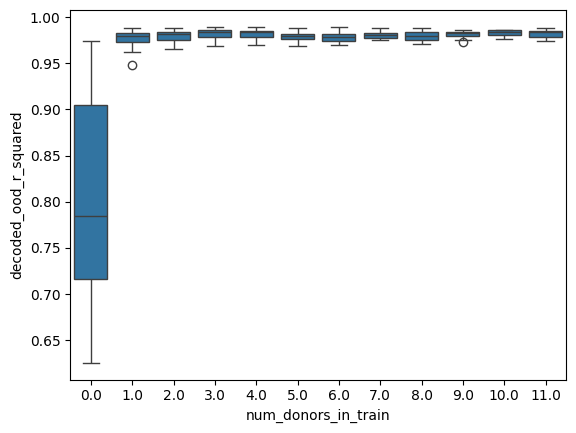

In [66]:
sns.boxplot(df_old_ifn_eps, x="num_donors_in_train", y="decoded_ood_r_squared")

In [58]:
df["cytokine"].unique()

array(['IFN-epsilon', 'C5a', 'IFN-beta'], dtype=object)

In [21]:
#df_old = df_old.rename(columns={col: f"{col}_old" for col in df_old.columns})

In [22]:
pd.merge(df, df_old, left_index=True, right_index=True)

,mean_decoded_r_sq_per_cell_type_x,mean_e_distance_per_cell_type_x,mean_mmd_per_cell_type_x,mean_sdiv_10_per_cell_type_x,mean_sdiv_100_per_cell_type_x,mean_deg_r_sq_per_cell_type_x,mean_deg_e_distance_per_cell_type_x,mean_deg_mmd_per_cell_type_x,mean_deg_sdiv_10_per_cell_type_x,mean_deg_sdiv_100_per_cell_type_x,...,div_10_pDC,div_100_pDC,deg_decoded_r_squared_pDC,deg_e_distance_pDC,deg_mmd_pDC,deg_div_10_pDC,deg_div_100_pDC,donor_cytokine_y,donor_y,cytokine_y
Donor9_IFN-epsilon,0.758201,219.983403,0.067857,215.649479,124.94846,0.498371,84.759818,0.079651,163.179505,50.697690,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Donor9_IFN-epsilon,Donor9,IFN-epsilon
Donor9_IFN-epsilon,0.758201,219.983403,0.067857,215.649479,124.94846,0.498371,84.759818,0.079651,163.179505,50.697690,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Donor9_IFN-epsilon,Donor9,IFN-epsilon
Donor9_IFN-epsilon,0.758201,219.983403,0.067857,215.649479,124.94846,0.498371,84.759818,0.079651,163.179505,50.697690,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Donor9_IFN-epsilon,Donor9,IFN-epsilon
Donor9_IFN-epsilon,0.758201,219.983403,0.067857,215.649479,124.94846,0.498371,84.759818,0.079651,163.179505,50.697690,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Donor9_IFN-epsilon,Donor9,IFN-epsilon
Donor9_IFN-epsilon,0.758201,219.983403,0.067857,215.649479,124.94846,0.498371,84.759818,0.079651,163.179505,50.697690,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Donor9_IFN-epsilon,Donor9,IFN-epsilon
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Donor9_C5a,0.926713,24.617335,0.017798,104.268237,21.16295,0.724585,40.718839,0.060286,150.497826,32.488521,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Donor9_C5a,Donor9,C5a
Donor9_C5a,0.926713,24.617335,0.017798,104.268237,21.16295,0.724585,40.718839,0.060286,150.497826,32.488521,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Donor9_C5a,Donor9,C5a
Donor9_C5a,0.926713,24.617335,0.017798,104.268237,21.16295,0.724585,40.718839,0.060286,150.497826,32.488521,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Donor9_C5a,Donor9,C5a
Donor9_C5a,0.926713,24.617335,0.017798,104.268237,21.16295,0.724585,40.718839,0.060286,150.497826,32.488521,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Donor9_C5a,Donor9,C5a


In [23]:
len(df), len(df_old)

(94, 2628)

In [24]:
df_old = df_old[df.columns]

In [31]:
df["num_donors_in_train"].columns

AttributeError: 'Series' object has no attribute 'columns'

In [28]:
df_old.loc[list(df.index)].shape

(1500, 162)

In [29]:
df_old.shape

(2628, 162)

In [34]:
df_old

,mean_decoded_r_sq_per_cell_type,mean_e_distance_per_cell_type,mean_mmd_per_cell_type,mean_sdiv_10_per_cell_type,mean_sdiv_100_per_cell_type,mean_deg_r_sq_per_cell_type,mean_deg_e_distance_per_cell_type,mean_deg_mmd_per_cell_type,mean_deg_sdiv_10_per_cell_type,mean_deg_sdiv_100_per_cell_type,...,ood_mmd,ood_sdiv_10,ood_sdiv_100,predicted_deg_genes,wandb_name,donors_in_train,num_donors_in_train,donor_cytokine,donor,cytokine
Donor4_C5a,0.955791,11.660839,0.008871,90.671855,12.128944,0.873296,17.662023,0.040608,125.486287,17.470218,...,0.001591,96.696915,42.316925,"['ENSG00000289578', 'LINC00326', 'ENSG00000290...",sandy-sunset-102,['Donor10' 'Donor11' 'Donor12' 'Donor5' 'Donor...,6.0,Donor4_C5a,Donor4,C5a
Donor7_OX40L,0.922924,35.460599,0.013862,111.972876,25.847652,0.765109,35.802167,0.046710,147.587429,29.255601,...,0.000966,93.287430,13.291016,"['ENSG00000289578', 'HBA2', 'ENSG00000290421',...",revived-energy-466,['Donor8'],1.0,Donor7_OX40L,Donor7,OX40L
Donor10_C5a,0.948272,16.919249,0.010235,97.359693,15.502340,0.816124,25.159851,0.041936,139.200932,21.871986,...,0.002630,133.894104,62.504395,"['LINC00326', 'ENSG00000289578', 'ENSG00000290...",devout-lake-116,['Donor11' 'Donor12' 'Donor1' 'Donor2' 'Donor3...,11.0,Donor10_C5a,Donor10,C5a
Donor11_4-1BBL,0.931346,22.054480,0.014290,102.952084,17.665734,0.813616,24.228663,0.046342,151.745742,23.805972,...,0.002632,81.282616,14.724792,"['HBA2', 'ENSG00000290421', 'HCRT', 'ENSG00000...",dark-flower-174,['Donor4' 'Donor6'],2.0,Donor11_4-1BBL,Donor11,4-1BBL
Donor6_OSM,0.955859,13.854135,0.007579,96.074269,13.403070,0.880971,18.501366,0.038873,129.942240,16.470612,...,0.000610,103.696564,23.837158,"['HBA1', 'HBA2', 'ENSG00000290421', 'LINC00326...",avid-leaf-436,['Donor11' 'Donor3' 'Donor4' 'Donor8' 'Donor9'],5.0,Donor6_OSM,Donor6,OSM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Donor6_ADSF,0.956680,14.770928,0.008126,95.846046,13.717383,0.858515,21.061358,0.044070,138.512497,18.308916,...,0.000619,104.889183,24.677521,"['HBA1', 'LINC00326', 'ENSG00000290421', 'HBA2...",zany-galaxy-237,['Donor10' 'Donor12' 'Donor1' 'Donor2' 'Donor3...,9.0,Donor6_ADSF,Donor6,ADSF
Donor2_IL-15,0.861882,63.065034,0.022514,121.993101,40.729307,0.281512,109.193320,0.061913,192.420882,65.541132,...,0.004135,150.882416,70.047241,"['LINC00326', 'ENSG00000289578', 'HBA1', 'ENSG...",elated-serenity-550,['Donor1' 'Donor4'],2.0,Donor2_IL-15,Donor2,IL-15
Donor6_IL-13,0.914972,48.879573,0.018992,112.713454,31.682600,0.593236,67.018556,0.058765,157.326407,40.127274,...,0.003135,101.360321,25.210083,"['HBA1', 'HBA2', 'LINC00326', 'HBB', 'NWD2', '...",peach-morning-513,['Donor1' 'Donor5' 'Donor9'],3.0,Donor6_IL-13,Donor6,IL-13
Donor12_IFN-epsilon,0.933152,18.536214,0.008800,106.017575,19.846786,0.824362,20.515010,0.037777,145.886677,20.150913,...,0.000577,90.943359,17.139526,"['HBA2', 'HBA1', 'HBB', 'ENSG00000290421', 'NP...",faithful-brook-45,['Donor4' 'Donor6'],2.0,Donor12_IFN-epsilon,Donor12,IFN-epsilon


In [36]:
df.head()

,mean_decoded_r_sq_per_cell_type,mean_e_distance_per_cell_type,mean_mmd_per_cell_type,mean_sdiv_10_per_cell_type,mean_sdiv_100_per_cell_type,mean_deg_r_sq_per_cell_type,mean_deg_e_distance_per_cell_type,mean_deg_mmd_per_cell_type,mean_deg_sdiv_10_per_cell_type,mean_deg_sdiv_100_per_cell_type,...,ood_mmd,ood_sdiv_10,ood_sdiv_100,predicted_deg_genes,wandb_name,donors_in_train,num_donors_in_train,donor_cytokine,donor,cytokine
Donor9_IFN-epsilon,0.758201,219.983403,0.067857,215.649479,124.948460,0.498371,84.759818,0.079651,163.179505,50.697690,...,0.030421,728.074402,608.378662,"['LINC00326', 'HBA1', 'ENSG00000290421', 'HBA2...",serene-bird-70,"['Donor10', 'Donor11', 'Donor12', 'Donor1', 'D...",11.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon
Donor9_C5a,0.924519,28.493989,0.018952,106.070607,23.040365,0.708883,42.793796,0.061164,151.682995,33.526622,...,0.002587,157.186752,77.541443,"['ENSG00000290421', 'ENSG00000229066', 'HBA1',...",dandy-blaze-81,"['Donor12', 'Donor1']",2.0,Donor9_C5a,Donor9,C5a
Donor9_IFN-beta,0.879416,63.608701,0.030753,134.995363,45.127221,0.659536,64.388435,0.059420,171.587436,45.726903,...,0.004353,128.247223,41.007568,"['HBA1', 'ENSG00000290421', 'LINC00326', 'HBA2...",gallant-music-14,"['Donor10', 'Donor1', 'Donor2', 'Donor6', 'Don...",6.0,Donor9_IFN-beta,Donor9,IFN-beta
Donor9_IFN-epsilon,0.889845,63.078893,0.033002,132.882067,47.283294,0.782381,37.873028,0.063327,135.715759,27.019095,...,0.010161,318.243164,212.762360,"['LINC00326', 'NPHS1', 'ENSG00000290421', 'HBA...",restful-salad-60,"['Donor10', 'Donor11', 'Donor12', 'Donor1', 'D...",9.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon
Donor9_C5a,0.916794,33.077449,0.020732,107.581138,25.008428,0.655681,50.450858,0.064446,155.186840,37.431915,...,0.003248,173.418335,92.314392,"['HBA2', 'ENSG00000290421', 'HBB', 'ENSG000002...",graceful-sunset-76,[],0.0,Donor9_C5a,Donor9,C5a


In [41]:
df_old["id"] = df_old["donor"] + "_" + df_old["cytokine"] + "_" + df_old["donors_in_train"] 
df["id"] = df["donor"] + "_" + df["cytokine"] + "_" + df["donors_in_train"] 

/tmp/ipykernel_2496992/2243344633.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["id"] = df["donor"] + "_" + df["cytokine"] + "_" + df["donors_in_train"]


In [42]:
df_old_red = df_old[df_old["id"].isin(df["id"].values)]

In [45]:
df["id"].values

array(["Donor9_IFN-epsilon_['Donor10', 'Donor11', 'Donor12', 'Donor1', 'Donor2', 'Donor3', 'Donor5', 'Donor6', 'Donor7', 'Donor8', 'Donor9']",
       "Donor9_C5a_['Donor12', 'Donor1']",
       "Donor9_IFN-beta_['Donor10', 'Donor1', 'Donor2', 'Donor6', 'Donor7', 'Donor9']",
       "Donor9_IFN-epsilon_['Donor10', 'Donor11', 'Donor12', 'Donor1', 'Donor2', 'Donor3', 'Donor4', 'Donor8', 'Donor9']",
       'Donor9_C5a_[]', "Donor9_C5a_['Donor3', 'Donor8']",
       "Donor9_IFN-epsilon_['Donor10', 'Donor2', 'Donor3', 'Donor4', 'Donor6', 'Donor7', 'Donor9']",
       "Donor9_C5a_['Donor6', 'Donor8']",
       "Donor9_IFN-beta_['Donor10', 'Donor2', 'Donor3']",
       "Donor9_C5a_['Donor11', 'Donor2', 'Donor9']",
       "Donor9_IFN-epsilon_['Donor10', 'Donor11', 'Donor12', 'Donor2', 'Donor3', 'Donor4', 'Donor5', 'Donor6', 'Donor7', 'Donor9']",
       "Donor9_IFN-beta_['Donor9']", "Donor9_C5a_['Donor9']",
       "Donor9_IFN-epsilon_['Donor1', 'Donor5', 'Donor6', 'Donor7']",
       "Donor9_IFN-beta_[

In [38]:
df_old["donors_in_train"]

Donor4_C5a             ['Donor10' 'Donor11' 'Donor12' 'Donor5' 'Donor...
Donor7_OX40L                                                  ['Donor8']
Donor10_C5a            ['Donor11' 'Donor12' 'Donor1' 'Donor2' 'Donor3...
Donor11_4-1BBL                                       ['Donor4' 'Donor6']
Donor6_OSM               ['Donor11' 'Donor3' 'Donor4' 'Donor8' 'Donor9']
                                             ...                        
Donor6_ADSF            ['Donor10' 'Donor12' 'Donor1' 'Donor2' 'Donor3...
Donor2_IL-15                                         ['Donor1' 'Donor4']
Donor6_IL-13                                ['Donor1' 'Donor5' 'Donor9']
Donor12_IFN-epsilon                                  ['Donor4' 'Donor6']
Donor2_C5a             ['Donor10' 'Donor11' 'Donor12' 'Donor1' 'Donor...
Name: donors_in_train, Length: 2628, dtype: object

In [39]:
df["donors_in_train"]

Donor9_IFN-epsilon    ['Donor10', 'Donor11', 'Donor12', 'Donor1', 'D...
Donor9_C5a                                        ['Donor12', 'Donor1']
Donor9_IFN-beta       ['Donor10', 'Donor1', 'Donor2', 'Donor6', 'Don...
Donor9_IFN-epsilon    ['Donor10', 'Donor11', 'Donor12', 'Donor1', 'D...
Donor9_C5a                                                           []
                                            ...                        
Donor9_IFN-epsilon                                          ['Donor11']
Donor9_IFN-beta       ['Donor10', 'Donor11', 'Donor12', 'Donor3', 'D...
Donor9_C5a                                                   ['Donor6']
Donor9_IFN-beta       ['Donor10', 'Donor11', 'Donor1', 'Donor2', 'Do...
Donor9_C5a                               ['Donor3', 'Donor6', 'Donor7']
Name: donors_in_train, Length: 94, dtype: object

In [37]:
df_old[(df_old["donor"]=="Donor9")&(df_old["cytokine"]=="IFN-epsilon")]

,mean_decoded_r_sq_per_cell_type,mean_e_distance_per_cell_type,mean_mmd_per_cell_type,mean_sdiv_10_per_cell_type,mean_sdiv_100_per_cell_type,mean_deg_r_sq_per_cell_type,mean_deg_e_distance_per_cell_type,mean_deg_mmd_per_cell_type,mean_deg_sdiv_10_per_cell_type,mean_deg_sdiv_100_per_cell_type,...,ood_mmd,ood_sdiv_10,ood_sdiv_100,predicted_deg_genes,wandb_name,donors_in_train,num_donors_in_train,donor_cytokine,donor,cytokine
Donor9_IFN-epsilon,0.940737,16.734151,0.010123,95.791318,16.704206,0.864856,22.645522,0.051908,125.899282,18.909221,...,0.000548,83.596878,15.275513,"['ENSG00000290421', 'ENSG00000229066', 'HBA2',...",faithful-brook-45,['Donor4' 'Donor6'],2.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon
Donor9_IFN-epsilon,0.939165,16.766339,0.010074,94.709079,16.679090,0.864636,22.633864,0.053935,124.830936,18.950982,...,0.000553,86.952515,18.922577,"['ENSG00000290421', 'NPHS1', 'HBA2', 'ENSG0000...",splendid-feather-53,['Donor1' 'Donor5' 'Donor6' 'Donor7'],4.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon
Donor9_IFN-epsilon,0.940030,17.052760,0.010050,95.378969,16.806109,0.863284,22.823080,0.052641,125.685109,19.010050,...,0.000528,81.656250,14.035828,"['ENSG00000290421', 'NPHS1', 'ENSG00000229066'...",sleek-music-51,['Donor3' 'Donor7' 'Donor8'],3.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon
Donor9_IFN-epsilon,0.940069,17.008730,0.010097,95.741295,17.052750,0.870420,21.649498,0.051514,125.438890,18.463619,...,0.000438,77.961151,10.788849,"['ENSG00000290421', 'NPHS1', 'ENSG00000229066'...",dulcet-cherry-42,['Donor11'],1.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon
Donor9_IFN-epsilon,0.941711,15.840084,0.009755,94.202184,16.029866,0.872828,21.309713,0.052860,124.741125,18.248729,...,0.000435,75.587357,9.168427,"['ENSG00000290421', 'NPHS1', 'ENSG00000229066'...",decent-cherry-48,['Donor11' 'Donor3'],2.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon
Donor9_IFN-epsilon,0.783401,203.186895,0.057731,199.642426,114.758698,0.447118,92.398872,0.080616,162.177824,54.117350,...,0.012502,187.126846,112.178589,"['HBA1', 'LINC00326', 'ENSG00000290421', 'HBA2...",exalted-dawn-44,[],0.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon
Donor9_IFN-epsilon,0.940838,16.212139,0.009953,94.395597,16.433883,0.875569,20.942012,0.054610,123.218507,18.081517,...,0.000474,84.549629,17.015533,"['ENSG00000290421', 'NPHS1', 'HBA2', 'ENSG0000...",distinctive-wildflower-54,['Donor11' 'Donor12' 'Donor1' 'Donor6'],4.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon
Donor9_IFN-epsilon,0.941590,16.180744,0.009796,94.242766,15.935711,0.870993,21.586248,0.051880,125.254628,18.400129,...,0.000501,85.365875,16.719238,"['ENSG00000290421', 'ENSG00000229066', 'NPHS1'...",scarlet-cloud-591,['Donor10' 'Donor11' 'Donor12' 'Donor1' 'Donor...,11.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon
Donor9_IFN-epsilon,0.941283,16.383358,0.010125,95.518825,16.464726,0.869177,21.963113,0.051515,125.890204,18.610176,...,0.000516,82.504608,14.425842,"['ENSG00000290421', 'ENSG00000229066', 'HBA2',...",wise-oath-55,['Donor10' 'Donor12' 'Donor2' 'Donor4' 'Donor6'],5.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon
Donor9_IFN-epsilon,0.936474,17.827441,0.010568,95.750217,17.451330,0.844740,25.851420,0.054937,126.613141,20.578653,...,0.000621,85.112076,17.320709,"['ENSG00000290421', 'NPHS1', 'HBA2', 'ENSG0000...",ancient-sun-62,['Donor11' 'Donor12' 'Donor2' 'Donor3' 'Donor5...,6.0,Donor9_IFN-epsilon,Donor9,IFN-epsilon


In [9]:
#df.to_csv(os.path.join(data_dir, "metrics_new_cytokine.csv"))

In [10]:
df["cytokine"].value_counts()

cytokine
C5a            219
OX40L          219
4-1BBL         219
OSM            219
Noggin         219
IFN-beta       219
IFN-epsilon    219
IL-15          219
ADSF           219
IL-13          219
APRIL          219
BAFF           219
Name: count, dtype: int64

In [11]:
df["donor"].value_counts()

donor
Donor5     234
Donor12    228
Donor8     225
Donor7     222
Donor10    221
Donor9     221
Donor2     217
Donor3     216
Donor11    215
Donor1     214
Donor4     209
Donor6     206
Name: count, dtype: int64

In [12]:
df["num_donors_in_train"].value_counts()

num_donors_in_train
1.0     396
2.0     360
3.0     324
4.0     288
5.0     252
6.0     216
7.0     180
11.0    144
0.0     144
8.0     144
9.0     108
10.0     72
Name: count, dtype: int64

<Axes: xlabel='num_donors_in_train', ylabel='decoded_ood_r_squared'>

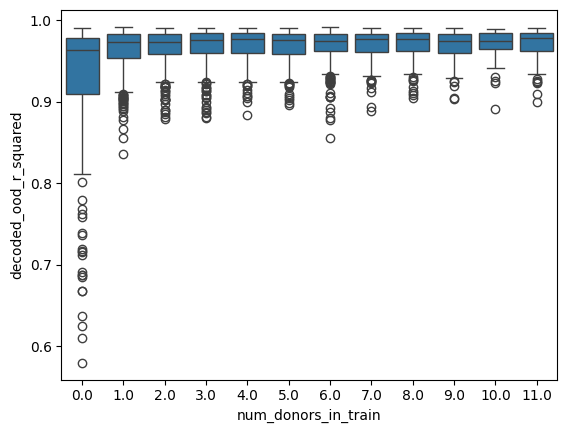

In [8]:
sns.boxplot(df, x="num_donors_in_train", y="decoded_ood_r_squared")

In [9]:
df["cytokine"].value_counts()

cytokine
IL-13          219
C5a            218
4-1BBL         218
OX40L          218
OSM            218
Noggin         218
IFN-epsilon    218
IFN-beta       218
IL-15          218
ADSF           218
APRIL          218
BAFF           218
Name: count, dtype: int64

In [15]:
[col for col in df.columns if col.startswith("num")]

['num_donors_in_train']

In [16]:
df["num_donors_in_train"].value_counts()

num_donors_in_train
1.0     396
2.0     360
3.0     324
4.0     288
5.0     252
6.0     216
7.0     180
0.0     144
8.0     144
11.0    133
9.0     108
10.0     72
Name: count, dtype: int64

<Axes: xlabel='num_donors_in_train', ylabel='ood_e_distance'>

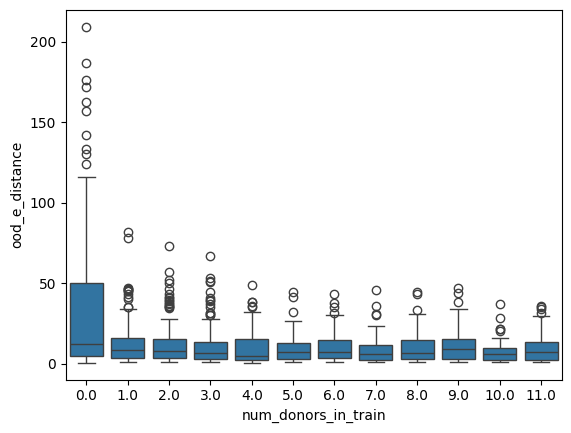

In [37]:
sns.boxplot(df, x="num_donors_in_train", y="ood_e_distance")

In [39]:
df.columns

Index(['mean_decoded_r_sq_per_cell_type', 'mean_e_distance_per_cell_type',
       'mean_mmd_per_cell_type', 'mean_sdiv_10_per_cell_type',
       'mean_sdiv_100_per_cell_type', 'mean_deg_r_sq_per_cell_type',
       'mean_deg_e_distance_per_cell_type', 'mean_deg_mmd_per_cell_type',
       'mean_deg_sdiv_10_per_cell_type', 'mean_deg_sdiv_100_per_cell_type',
       ...
       'decoded_r_squared_pDC', 'e_distance_pDC', 'mmd_pDC', 'div_10_pDC',
       'div_100_pDC', 'deg_decoded_r_squared_pDC', 'deg_e_distance_pDC',
       'deg_mmd_pDC', 'deg_div_10_pDC', 'deg_div_100_pDC'],
      dtype='object', length=169)

# Only for IFN-beta

/tmp/ipykernel_2936957/2027898116.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["cytokine"] = df.apply(lambda x: x["donor_cytokine"].split("_")[1], axis=1)


In [54]:
df.head()

,mean_decoded_r_sq_per_cell_type,mean_e_distance_per_cell_type,mean_mmd_per_cell_type,mean_sdiv_10_per_cell_type,mean_sdiv_100_per_cell_type,mean_deg_r_sq_per_cell_type,mean_deg_e_distance_per_cell_type,mean_deg_mmd_per_cell_type,mean_deg_sdiv_10_per_cell_type,mean_deg_sdiv_100_per_cell_type,...,div_10_pDC,div_100_pDC,deg_decoded_r_squared_pDC,deg_e_distance_pDC,deg_mmd_pDC,deg_div_10_pDC,deg_div_100_pDC,donor_cytokine,donor,cytokine
Donor6_OSM,0.955859,13.854135,0.007579,96.074269,13.403070,0.880971,18.501366,0.038873,129.942240,16.470612,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Donor6_OSM,Donor6,OSM
Donor3_Noggin,0.948423,10.337789,0.008039,85.430818,11.438399,0.861379,21.042687,0.046040,129.693424,19.642050,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Donor3_Noggin,Donor3,Noggin
Donor9_IFN-beta,0.911771,37.328266,0.018902,115.635271,31.482062,0.745882,47.401039,0.053524,159.542881,36.927231,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Donor9_IFN-beta,Donor9,IFN-beta
Donor9_IFN-beta,0.911994,37.142666,0.018770,114.777701,30.014668,0.754597,45.861869,0.053164,158.575233,36.014094,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Donor9_IFN-beta,Donor9,IFN-beta
Donor2_IL-15,0.792532,131.248214,0.038466,156.664776,75.370069,-0.149577,177.003031,0.078456,228.298813,100.057185,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Donor2_IL-15,Donor2,IL-15


In [46]:
df_ifn_beta = df[df["cytokine"]=="IFN-beta"]

KeyError: 'cytokine'

<Axes: xlabel='num_donors', ylabel='decoded_ood_r_squared'>

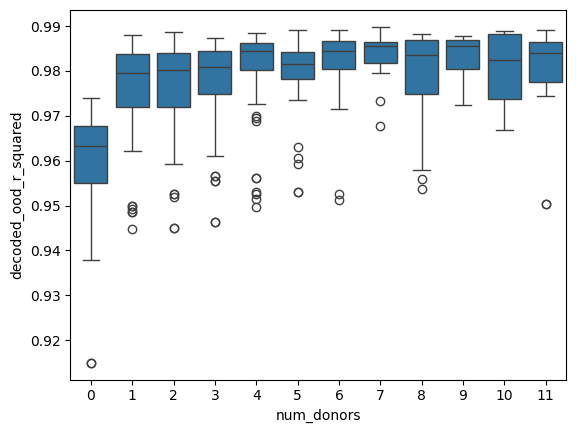

In [12]:
sns.boxplot(df_ifn_beta, x="num_donors", y="decoded_ood_r_squared")

<Axes: xlabel='num_donors', ylabel='ood_mmd'>

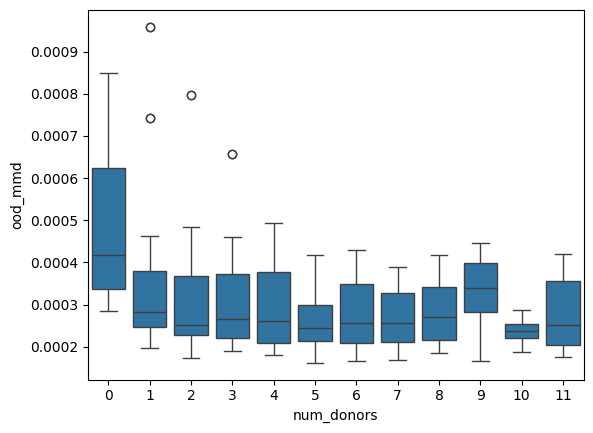

In [13]:
sns.boxplot(df_ifn_beta, x="num_donors", y="ood_mmd")

# Only for IFN-epsilon

In [17]:
df_ifn_eps = df_res[df_res["cytokine"]=="IFN-epsilon"]

<Axes: xlabel='num_donors', ylabel='ood_mmd'>

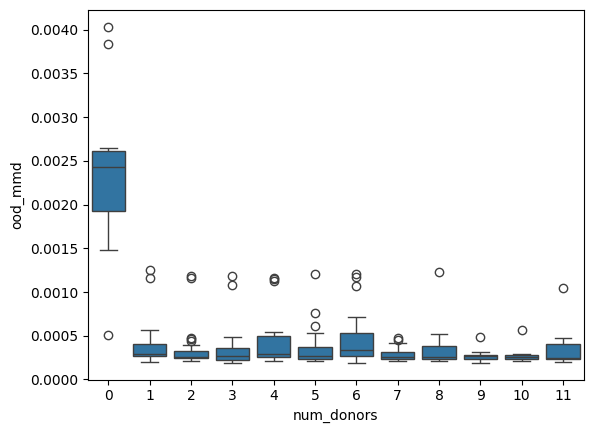

In [18]:
sns.boxplot(df_ifn_eps, x="num_donors", y="ood_mmd")

<Axes: xlabel='num_donors', ylabel='decoded_ood_r_squared'>

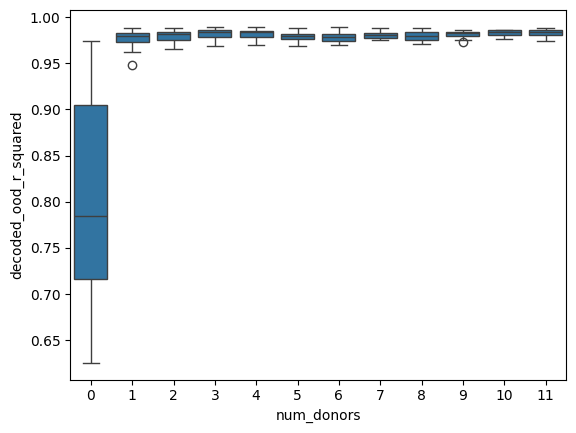

In [19]:
sns.boxplot(df_ifn_eps, x="num_donors", y="decoded_ood_r_squared")

<Axes: xlabel='num_donors', ylabel='decoded_ood_r_squared'>

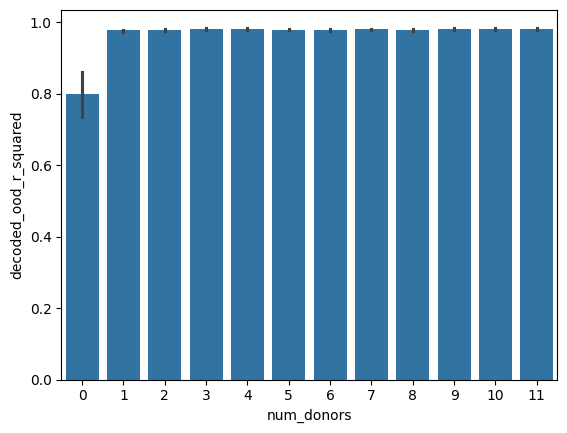

In [51]:
sns.barplot(df_ifn_eps, x="num_donors", y="decoded_ood_r_squared")

# Only for Donor 1

In [20]:
df_d1 = df_res[df_res["donor"]=="Donor1"]

In [21]:
df_d1["num_donors"].value_counts()

num_donors
1     37
2     36
3     30
4     23
6     20
5     18
7     17
9     14
11    13
0     13
8      8
10     6
Name: count, dtype: int64

<Axes: xlabel='num_donors', ylabel='decoded_ood_r_squared'>

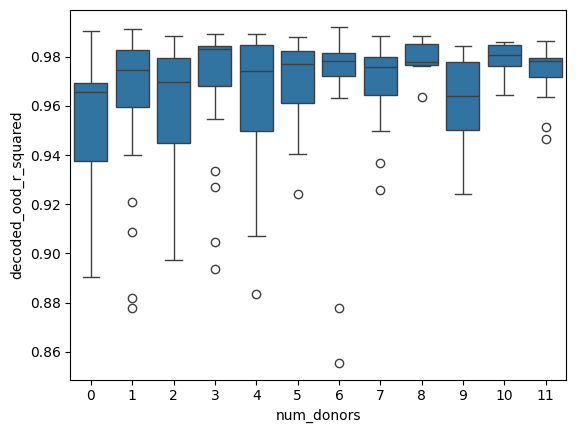

In [23]:
sns.boxplot(df_d1, x="num_donors", y="decoded_ood_r_squared")

<Axes: xlabel='num_donors', ylabel='ood_mmd'>

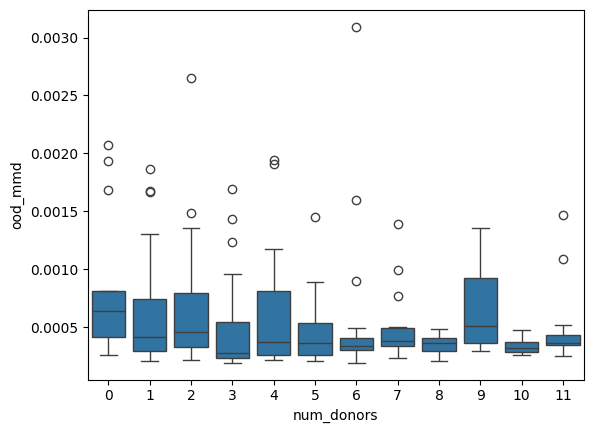

In [24]:
sns.boxplot(df_d1, x="num_donors", y="ood_mmd")

# Only for Donor 2

In [52]:
df_d2 = df_res[df_res["donor"]=="Donor4"]

<Axes: xlabel='num_donors', ylabel='decoded_ood_r_squared'>

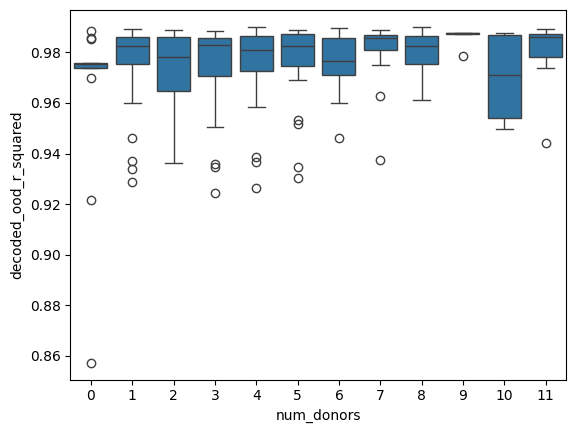

In [53]:
sns.boxplot(df_d2, x="num_donors", y="decoded_ood_r_squared")

<Axes: xlabel='num_donors', ylabel='ood_mmd'>

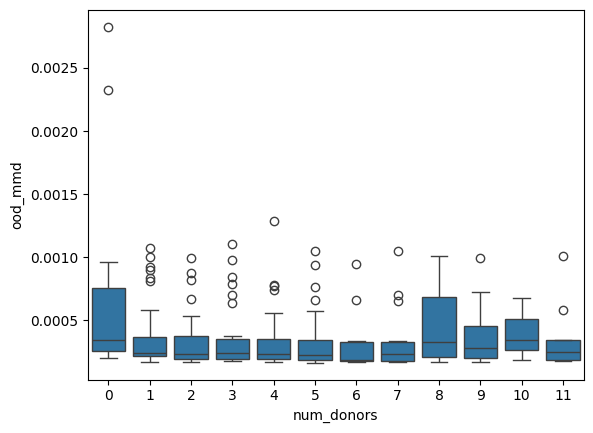

In [27]:
sns.boxplot(df_d2, x="num_donors", y="ood_mmd")

In [28]:
df_res

,cytokine,donor,ood_mmd,ood_e_distance,decoded_ood_r_squared,num_donors,donors_in_train
0,ADSF,Donor11,0.000351,5.668417,0.980433,4,"[b'Donor12', b'Donor3', b'Donor4', b'Donor5']"
1,CD27L,Donor7,0.000208,2.902274,0.983814,3,"[b'Donor12', b'Donor2', b'Donor9']"
2,BAFF,Donor4,0.000393,3.345567,0.986852,4,"[b'Donor12', b'Donor1', b'Donor5', b'Donor6']"
3,4-1BBL,Donor11,0.000930,12.243304,0.961728,3,"[b'Donor12', b'Donor2', b'Donor8']"
4,APRIL,Donor10,0.001248,21.105317,0.962782,6,"[b'Donor2', b'Donor3', b'Donor5', b'Donor6', b..."
...,...,...,...,...,...,...,...
2822,C5a,Donor6,0.000400,16.141060,0.962497,6,"[b'Donor10', b'Donor1', b'Donor2', b'Donor4', ..."
2823,Noggin,Donor11,0.000368,5.526193,0.977623,2,"[b'Donor8', b'Donor9']"
2824,IL-13,Donor12,0.000561,18.224097,0.939325,7,"[b'Donor11', b'Donor2', b'Donor4', b'Donor5', ..."
2825,BAFF,Donor3,0.000310,4.773738,0.987325,3,"[b'Donor1', b'Donor7', b'Donor9']"


# Check if we have a significant dependence of model accuracy of donors being included

In [170]:
df_res.head()

,cytokine,donor,ood_mmd,ood_e_distance,decoded_ood_r_squared,num_donors,donors_in_train
0,ADSF,Donor11,0.000351,5.668417,0.980433,4,"[b'Donor12', b'Donor3', b'Donor4', b'Donor5']"
1,CD27L,Donor7,0.000208,2.902274,0.983814,3,"[b'Donor12', b'Donor2', b'Donor9']"
2,BAFF,Donor4,0.000393,3.345567,0.986852,4,"[b'Donor12', b'Donor1', b'Donor5', b'Donor6']"
3,4-1BBL,Donor11,0.000930,12.243304,0.961728,3,"[b'Donor12', b'Donor2', b'Donor8']"
4,APRIL,Donor10,0.001248,21.105317,0.962782,6,"[b'Donor2', b'Donor3', b'Donor5', b'Donor6', b..."


In [18]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split


def get_donor_importance(df_res: pd.DataFrame, donor: str, target_variable: str = "decoded_ood_r_squared"):
    all_donors = df_res["donor"].unique()
    df_d = df_res[df_res["donor"]==donor]
    for d in all_donors:
        df_d[f"{d}_present"] = df_d.apply(lambda x: d in x["donors_in_train"].astype(str), axis=1)

    for num_donor in df_res["num_donors"].unique():
        df_d[f"{num_donor}_present"] = df_d.apply(lambda x: x["num_donors"] == num_donor, axis=1)
    
    cols = [f"{d}_present" for d in all_donors if d!=donor] + [f"{num_donor}_present" for num_donor in df_res["num_donors"].unique()] 
    X = df_d[cols]
    y = df_d[target_variable]
    X = sm.add_constant(X)
    model = sm.OLS(y.values, np.float64(X.values)).fit()
    coefficients = model.params
    p_values = model.pvalues
    
    feature_stats = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': coefficients,
        'P-Value': p_values
    }).sort_values(by='P-Value')
    return feature_stats


In [30]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler


def get_donor_importance(df_res: pd.DataFrame, donor: str, target_variable: str = "decoded_ood_r_squared", alpha: float = 0.1):
    # Get unique donors
    all_donors = df_res["donor"].unique()
    
    # Filter for the specific donor
    df_d = df_res[df_res["donor"] == donor]
    
    # Create binary columns for donors in training
    for d in all_donors:
        df_d[f"{d}_present"] = df_d.apply(lambda x: d in x["donors_in_train"].astype(str), axis=1)
    
    # Create binary columns for number of donors
    for num_donor in df_d["num_donors"].unique():
        df_d[f"{num_donor}_present"] = df_d.apply(lambda x: x["num_donors"] == num_donor, axis=1)
    
    # Define feature columns
    cols = [f"{d}_present" for d in all_donors if d != donor] + \
           [f"{num_donor}_present" for num_donor in df_d["num_donors"].unique()]
    
    # Prepare feature matrix and target variable
    X = df_d[cols]
    y = df_d[target_variable]
    
    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Fit Lasso regression
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_scaled, y)
    
    # Extract coefficients
    coefficients = lasso.coef_
    intercept = lasso.intercept_
    
    # Create a DataFrame with feature importance
    feature_stats = pd.DataFrame({
        'Feature': cols,
        'Coefficient': coefficients
    }).sort_values(by='Coefficient', ascending=False)
    
    # Add the intercept for completeness
    feature_stats.loc[len(feature_stats)] = ['Intercept', intercept]
    
    return feature_stats


In [33]:
df_res.head()

,cytokine,donor,ood_mmd,ood_e_distance,decoded_ood_r_squared,num_donors,donors_in_train
0,ADSF,Donor11,0.000351,5.668417,0.980433,4,"[b'Donor12', b'Donor3', b'Donor4', b'Donor5']"
1,CD27L,Donor7,0.000208,2.902274,0.983814,3,"[b'Donor12', b'Donor2', b'Donor9']"
2,BAFF,Donor4,0.000393,3.345567,0.986852,4,"[b'Donor12', b'Donor1', b'Donor5', b'Donor6']"
3,4-1BBL,Donor11,0.000930,12.243304,0.961728,3,"[b'Donor12', b'Donor2', b'Donor8']"
4,APRIL,Donor10,0.001248,21.105317,0.962782,6,"[b'Donor2', b'Donor3', b'Donor5', b'Donor6', b..."


In [53]:
donor_cols = [f"{d}_present" for d in df_res["donor"].unique()] + [f"{num_donor}_present" for num_donor in df_res["num_donors"].unique()] 
df_pvals = pd.DataFrame(columns=donor_cols)
df_c = pd.DataFrame(columns=donor_cols)
for donor in df_res["donor"].unique():
    d = get_donor_importance(df_res, donor, "decoded_ood_r_squared", alpha=0.0005).set_index("Feature")
    d.loc[f"{donor}_present"] = None
    #df_pvals.loc[donor] = d.loc[donor_cols]["P-Value"]
    df_c.loc[donor] = d.loc[donor_cols]["Coefficient"]
    

/tmp/ipykernel_2154944/2207591824.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_d[f"{d}_present"] = df_d.apply(lambda x: d in x["donors_in_train"].astype(str), axis=1)
/tmp/ipykernel_2154944/2207591824.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_d[f"{d}_present"] = df_d.apply(lambda x: d in x["donors_in_train"].astype(str), axis=1)
/tmp/ipykernel_2154944/2207591824.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

In [45]:
df_c

,Donor11_present,Donor7_present,Donor4_present,Donor10_present,Donor12_present,Donor2_present,Donor6_present,Donor1_present,Donor5_present,Donor9_present,...,6_present,2_present,8_present,5_present,0_present,1_present,11_present,10_present,9_present,7_present
Donor11,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.0,-0.0,0.0,0.0,-0.003607,-0.0,0.0,0.0,0.0,0.0
Donor7,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.0,-0.004194,0.0,0.0,0.0,0.0,0.0
Donor4,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-0.0,0.0,-0.0,-0.000000,0.0,0.0,-0.0,0.0,0.0
Donor10,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-0.0,0.0,-0.0,-0.000000,-0.0,0.0,0.0,0.0,0.0
Donor12,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,-0.0,0.0,0.0,-0.005927,-0.0,0.0,0.0,0.0,0.0
Donor2,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,...,-0.0,0.0,-0.0,0.0,-0.001968,0.0,0.0,0.0,-0.0,0.0
Donor6,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,-0.000531,-0.0,0.0,0.0,0.0,-0.0
Donor1,0.0,0.0,0.0,-0.0,-0.0,0.0,0.0,NaN,0.0,0.0,...,0.0,-0.0,0.0,0.0,-0.000000,-0.0,0.0,0.0,-0.0,0.0
Donor5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,...,0.0,0.0,0.0,-0.0,-0.003007,-0.0,0.0,0.0,0.0,0.0
Donor9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,0.0,-0.0,0.0,0.0,-0.005715,-0.0,0.0,0.0,0.0,0.0


In [46]:
(df_c!=0).sum(axis=0)

Donor11_present    1
Donor7_present     1
Donor4_present     1
Donor10_present    1
Donor12_present    1
Donor2_present     1
Donor6_present     1
Donor1_present     1
Donor5_present     1
Donor9_present     1
Donor3_present     1
Donor8_present     1
4_present          0
3_present          0
6_present          0
2_present          0
8_present          0
5_present          0
0_present          8
1_present          0
11_present         0
10_present         0
9_present          0
7_present          0
dtype: int64

<Axes: >

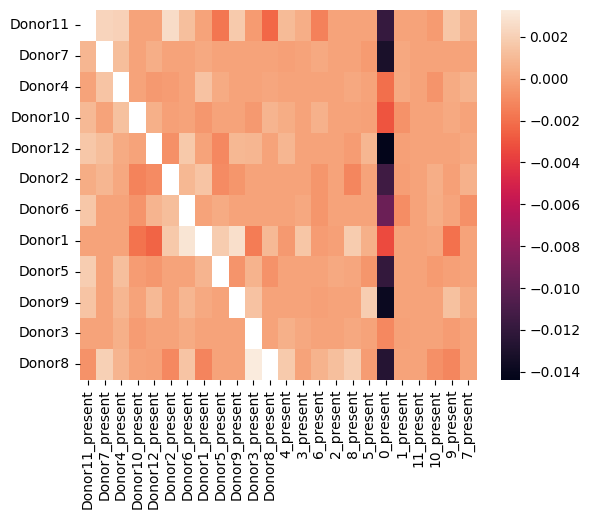

In [54]:
sns.heatmap(df_c)

In [55]:
df_c[df_c<0.0]=0.0

<Axes: >

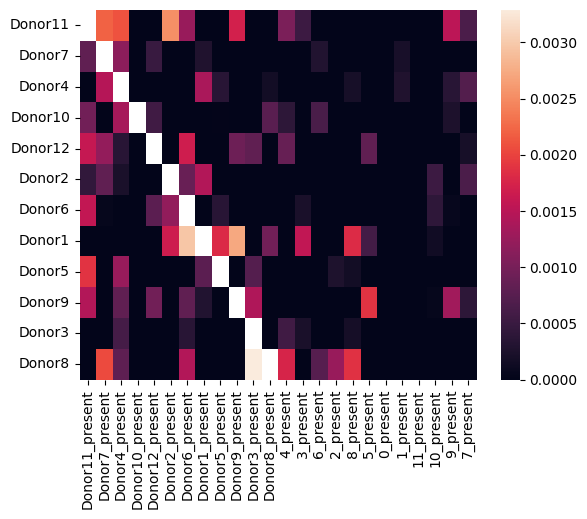

In [56]:
sns.heatmap(df_c)

In [24]:
(df_pvals<0.05/11).sum() # signficance without Bonferroni correction

Donor11_present     0
Donor7_present      0
Donor4_present      0
Donor10_present     0
Donor12_present     0
Donor2_present      0
Donor6_present      0
Donor1_present      0
Donor5_present      0
Donor9_present      0
Donor3_present      0
Donor8_present      0
4_present           0
3_present           0
6_present           0
2_present           0
8_present           0
5_present           0
0_present          12
1_present           0
11_present          0
10_present          0
9_present           0
7_present           0
dtype: int64

In [25]:
(df_pvals<0.05).sum() # signficance without Bonferroni correction

Donor11_present     0
Donor7_present      0
Donor4_present      2
Donor10_present     2
Donor12_present     0
Donor2_present      1
Donor6_present      0
Donor1_present      1
Donor5_present      0
Donor9_present      0
Donor3_present      0
Donor8_present      0
4_present           0
3_present           0
6_present           0
2_present           0
8_present           0
5_present           0
0_present          12
1_present           2
11_present          0
10_present          0
9_present           0
7_present           0
dtype: int64

In [26]:
df_pvals

,Donor11_present,Donor7_present,Donor4_present,Donor10_present,Donor12_present,Donor2_present,Donor6_present,Donor1_present,Donor5_present,Donor9_present,...,6_present,2_present,8_present,5_present,0_present,1_present,11_present,10_present,9_present,7_present
Donor11,NaN,0.499784,0.140938,0.722493,0.673386,0.046751,0.321837,0.939286,0.144841,0.303974,...,0.353377,0.631850,0.483659,0.914885,6.965433e-09,0.759180,0.917591,0.842286,0.297337,0.804667
Donor7,0.452476,NaN,0.239271,0.697583,0.500161,0.818940,0.571097,0.558846,0.936066,0.784855,...,0.722978,0.838740,0.907783,0.754006,2.580909e-10,0.469251,0.893788,0.798734,0.924529,0.773934
Donor4,0.980225,0.203563,NaN,0.889989,0.658034,0.922861,0.380902,0.206264,0.428522,0.675107,...,0.701191,0.472595,0.991395,0.386739,1.529544e-06,0.971408,0.847297,0.375800,0.185639,0.197853
Donor10,0.571208,0.907146,0.793909,NaN,0.068273,0.319985,0.680887,0.024811,0.402146,0.289294,...,0.530620,0.646908,0.753695,0.938701,1.478500e-07,0.022685,0.975413,0.616244,0.837805,0.611507
Donor12,0.143542,0.315977,0.342816,0.861446,NaN,0.457096,0.492131,0.879888,0.161820,0.592915,...,0.772017,0.889402,0.621359,0.474464,3.724295e-10,0.959263,0.936518,0.993627,0.804462,0.613736
Donor2,0.394178,0.330630,0.179982,0.150104,0.406411,NaN,0.727751,0.713926,0.236213,0.289341,...,0.828854,0.936738,0.377717,0.936469,1.326710e-07,0.761779,0.720399,0.962658,0.909744,0.737785
Donor6,0.429170,0.631711,0.866979,0.400970,0.365431,0.525729,NaN,0.863681,0.847187,0.962018,...,0.460461,0.873293,0.725117,0.608843,3.128725e-13,0.442670,0.899772,0.611126,0.960337,0.385684
Donor1,0.717380,0.731377,0.430109,0.048367,0.110043,0.399561,0.200607,NaN,0.166088,0.370341,...,0.282333,0.194590,0.195945,0.422543,2.082698e-05,0.649951,0.915533,0.514749,0.103751,0.867590
Donor5,0.208151,0.770707,0.336493,0.583901,0.581795,0.890021,0.803763,0.597663,NaN,0.511673,...,0.860716,0.781076,0.437089,0.722905,1.204538e-08,0.843092,0.658556,0.780400,0.560857,0.964818
Donor9,0.333242,0.813179,0.286206,0.543055,0.689030,0.996709,0.784793,0.776817,0.855243,NaN,...,0.486483,0.877564,0.773379,0.238054,4.129416e-10,0.873409,0.875345,0.941434,0.631331,0.993293


In [47]:
# Now do this analysis for every cytokine separately
ps={}
df_cs = {}
df_ps = {}

for cyto in df_res["cytokine"].unique():
    df_res_c = df_res[df_res["cytokine"]==cyto]
    donor_cols = [f"{d}_present" for d in df_res_c["donor"].unique()]
    df_pvals = pd.DataFrame(columns=donor_cols)
    df_c = pd.DataFrame(columns=donor_cols)
    for donor in df_res_c["donor"].unique():
        d = get_donor_importance(df_res_c, donor, "ood_mmd").set_index("Feature")
        d.loc[f"{donor}_present"] = None
        df_pvals.loc[donor] = d.loc[donor_cols]["P-Value"]
        df_c.loc[donor] = d.loc[donor_cols]["Coefficient"]
    ps[cyto] = (df_pvals<0.05/11).sum().sum()
    df_ps[cyto] = df_pvals
    df_cs[cyto] = df_c


/tmp/ipykernel_3016015/899926805.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_d[f"{d}_present"] = df_d.apply(lambda x: d in x["donors_in_train"].astype(str), axis=1)
/tmp/ipykernel_3016015/899926805.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_d[f"{d}_present"] = df_d.apply(lambda x: d in x["donors_in_train"].astype(str), axis=1)
/tmp/ipykernel_3016015/899926805.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer

In [48]:
ps

{'ADSF': 1,
 'CD27L': 7,
 'BAFF': 1,
 '4-1BBL': 2,
 'APRIL': 4,
 'C5a': 1,
 'OSM': 0,
 'Noggin': 1,
 'OX40L': 1,
 'IFN-epsilon': 0,
 'IFN-beta': 0,
 'IL-13': 1}

In [49]:
df_ps['CD27L']

,Donor7_present,Donor2_present,Donor5_present,Donor12_present,Donor9_present,Donor6_present,Donor1_present,Donor8_present,Donor3_present,Donor10_present,Donor4_present,Donor11_present
Donor7,NaN,0.071744,0.911285,0.490037,0.353620,0.953653,0.890036,9.870780e-01,0.632719,0.947270,0.160096,0.999814
Donor2,0.025492,NaN,0.239377,0.863037,0.238032,0.062917,0.205973,1.305661e-01,0.770957,0.737669,0.365346,0.613236
Donor5,0.046897,0.327949,NaN,0.026811,0.538709,0.020933,0.931003,9.406426e-05,0.890599,0.017117,0.326770,0.061015
Donor12,0.033831,0.016759,0.733256,NaN,0.359073,0.280661,0.729514,1.984962e-01,0.666285,0.316396,0.064145,0.324628
Donor9,0.636766,0.017123,0.065984,0.056453,NaN,0.442854,0.361998,6.489734e-01,0.760024,0.286867,0.007639,0.210799
Donor6,0.519093,0.014703,0.465866,0.681550,0.849902,NaN,0.695887,6.397578e-01,0.692401,0.029222,0.779379,0.023586
Donor1,0.000045,0.000171,0.070413,0.174339,0.034987,0.000096,NaN,2.213033e-13,0.405499,0.027445,0.912841,0.004022
Donor8,0.609906,0.223409,0.609177,0.496925,0.598594,0.296616,0.501610,NaN,0.819443,0.394058,0.271848,0.235709
Donor3,0.098421,0.012083,0.412598,0.899788,0.520161,0.225416,0.179006,9.704287e-02,NaN,0.171429,0.018755,0.582295
Donor10,0.783458,0.178376,0.417362,0.424334,0.648489,0.026557,0.161993,1.943763e-03,0.723654,NaN,0.050082,0.086903


In [50]:
df_cs['CD27L']

,Donor7_present,Donor2_present,Donor5_present,Donor12_present,Donor9_present,Donor6_present,Donor1_present,Donor8_present,Donor3_present,Donor10_present,Donor4_present,Donor11_present
Donor7,NaN,-0.000037,0.000002,-0.000012,0.000019,-9.405513e-07,-0.000003,2.612745e-07,-0.000007,0.000002,-0.000029,4.825791e-09
Donor2,-0.000049,NaN,-0.000026,0.000004,0.000031,-3.075944e-05,0.000034,-2.056257e-05,0.000005,-0.000007,-0.000011,-1.239791e-05
Donor5,-0.000017,-0.000011,NaN,-0.000026,0.000006,-2.891717e-05,0.000001,3.758881e-05,-0.000002,0.000036,0.000009,-3.942277e-05
Donor12,-0.000029,-0.000028,-0.000005,NaN,0.000013,-1.050079e-05,0.000006,1.018634e-05,-0.000005,0.000015,-0.000014,-1.582316e-05
Donor9,0.000011,-0.000069,-0.000056,0.000050,NaN,-1.442186e-05,-0.000022,-7.456995e-06,-0.000006,-0.000037,-0.000059,4.732569e-05
Donor6,-0.000012,-0.000049,-0.000016,-0.000005,0.000004,NaN,-0.000008,-6.824278e-06,-0.000007,0.000054,-0.000004,-5.222183e-05
Donor1,-0.000151,-0.000158,-0.000054,-0.000044,0.000095,-1.563640e-04,NaN,3.420537e-04,0.000031,0.000084,-0.000003,-9.506847e-05
Donor8,-0.000018,-0.000050,0.000022,-0.000019,-0.000022,-3.816183e-05,0.000035,NaN,-0.000008,0.000037,-0.000036,-5.239059e-05
Donor3,-0.000046,-0.000065,-0.000026,-0.000003,0.000016,-2.582133e-05,0.000051,-3.898995e-05,NaN,0.000033,-0.000048,1.556284e-05
Donor10,-0.000023,-0.000086,0.000062,0.000052,-0.000031,-1.539659e-04,-0.000123,2.241235e-04,-0.000019,NaN,-0.000109,-1.440552e-04


In [39]:
df_pvals

,Donor8_present,Donor3_present,Donor1_present,Donor9_present,Donor11_present,Donor5_present,Donor12_present,Donor6_present,Donor2_present,Donor7_present,Donor4_present,Donor10_present
Donor8,NaN,0.011237,0.133659,0.605596,0.174373,0.691606,0.922070,0.237615,0.058348,0.848052,0.956500,0.112185
Donor3,0.966189,NaN,0.142145,0.206521,0.866141,0.904220,0.168004,0.405131,0.102518,0.154221,0.400418,0.112328
Donor1,0.595063,0.089532,NaN,0.644648,0.717148,0.677856,0.509268,0.541052,0.547773,0.499899,0.582347,0.786616
Donor9,0.765450,0.161363,0.640398,NaN,0.403875,0.174639,0.210125,0.328424,0.641610,0.294881,0.635940,0.749736
Donor11,0.696855,0.211465,0.622297,0.844334,NaN,0.487812,0.573386,0.720521,0.189558,0.949484,0.898137,0.362629
Donor5,0.209953,0.003120,0.007768,0.390984,0.817104,NaN,0.043410,0.011440,0.006099,0.594514,0.634551,0.004899
Donor12,0.166270,0.054048,0.902067,0.818330,0.661513,0.291522,NaN,0.337773,0.584135,0.402534,0.482616,0.264645
Donor6,0.658125,0.017363,0.021366,0.276609,0.385467,0.942799,0.306433,NaN,0.121617,0.163650,0.419090,0.540349
Donor2,0.381213,0.114746,0.033688,0.554926,0.054946,0.455761,0.066733,0.993814,NaN,0.350486,0.428112,0.633109
Donor7,0.680997,0.346013,0.047862,0.720054,0.143289,0.510654,0.151870,0.882569,0.016443,NaN,0.217355,0.142554


In [40]:
df_c

,Donor8_present,Donor3_present,Donor1_present,Donor9_present,Donor11_present,Donor5_present,Donor12_present,Donor6_present,Donor2_present,Donor7_present,Donor4_present,Donor10_present
Donor8,NaN,-0.000132,0.000071,-0.000028,-0.000062,0.000021,-0.000006,-9.082281e-05,0.000080,-0.000011,-0.000003,-0.000104
Donor3,-0.000010,NaN,0.000143,-0.000162,0.000028,0.000014,-0.000201,1.112832e-04,0.000203,-0.000331,0.000155,-0.000162
Donor1,-0.000383,0.000556,NaN,0.000169,-0.000177,-0.000210,0.000219,-2.684574e-04,-0.000169,0.000441,0.000272,-0.000082
Donor9,-0.000015,-0.000032,-0.000015,NaN,-0.000023,-0.000061,-0.000063,-3.067944e-05,-0.000011,0.000042,-0.000020,0.000011
Donor11,-0.000195,-0.000274,0.000120,-0.000063,NaN,-0.000171,0.000196,-1.648416e-04,0.000293,-0.000020,0.000081,-0.000275
Donor5,-0.000057,0.000077,-0.000076,-0.000027,0.000006,NaN,-0.000089,1.228987e-04,-0.000084,-0.000013,0.000013,0.000115
Donor12,-0.000188,-0.000158,-0.000007,-0.000016,0.000035,-0.000107,NaN,1.231552e-04,-0.000036,0.000185,-0.000111,-0.000138
Donor6,0.000042,-0.000144,0.000126,-0.000075,0.000045,-0.000004,-0.000065,NaN,0.000095,-0.000143,-0.000061,-0.000041
Donor2,-0.000052,-0.000050,0.000065,-0.000022,-0.000071,0.000030,-0.000073,-4.223346e-07,NaN,-0.000045,0.000041,-0.000016
Donor7,-0.000010,0.000011,-0.000043,0.000004,-0.000028,-0.000012,-0.000030,2.629753e-06,-0.000044,NaN,0.000024,-0.000028


# How to recover what is missing

In [ ]:
import scanpy as sc
cytokine_held_out = "IL-13"
adata_rest = sc.read_h5ad(f"/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/new_cytokine/adata_rest_{cytokine_held_out}.h5ad")

len(adata_rest.uns["split_info"]["1"]['donors_to_impute'])

donors_imputed = []

i=0
for el in os.listdir(data_dir):
    if el.endswith(".csv"):
        if len(el.split("_")) < 4:
            continue
        
        cytokine = el.split("_")[-2]
        if cytokine != "IL-13":
            continue
        donors_imputed.append(get_donors_in_train(el))


result = []

# Iterate over the outer list
for j in range(len(donors_imputed)):
    # Iterate over the inner list
    tmp = []
    for i in range(len(donors_imputed[j][0])):
        # Extract and process the element
        processed_value = str(donors_imputed[j][0][i])[2:-1]
        # Append to the result list
        tmp.append(processed_value)
    result.append(set(sorted(tmp)))

idcs = []
for idx, config in adata_rest.uns["split_info"].items():
    if not set(sorted([el for el in config['donors_to_train_data']])) in result:
        idcs.append(int(idx))


print(idcs)

In [324]:
adata_pred = sc.read_h5ad("/lustre/groups/ml01/workspace/ot_perturbation/models/otfm/pbmc_new_donor_new/royal-water-3_Donor1_ADSF_preds.h5ad")

In [326]:
donor_held_out ="Donor1"
idx_given_donor= "1"
adata_train = sc.read_h5ad(f"/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/new_donor/{donor_held_out}/{str(idx_given_donor)}/adata_train_{donor_held_out}.h5ad")
adata_ood_perturbed  = sc.read_h5ad(f"/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/new_donor/{donor_held_out}/{str(idx_given_donor)}/adata_ood_{donor_held_out}.h5ad")


In [327]:
covariate_data = adata_ood_perturbed.obs.drop_duplicates(subset=["condition"])


In [328]:
covariate_data

,sample,species,gene_count,tscp_count,mread_count,bc1_wind,bc2_wind,bc3_wind,bc1_well,bc2_well,...,log1p_total_counts,total_counts_MT,pct_counts_MT,log1p_total_counts_MT,donor,cytokine,treatment,cell_type,condition,is_control
66_001_068__s1,Donor1_ADSF,hg38,2832,7509,14492,66,1,68,F6,A1,...,8.923991,127.0,1.691304,4.852030,Donor1,ADSF,cytokine,NK CD56bright,Donor1_ADSF,False
37_001_023__s1,Donor1_BAFF,hg38,2378,5394,9973,37,1,23,D1,A1,...,8.593228,98.0,1.816834,4.595120,Donor1,BAFF,cytokine,NK,Donor1_BAFF,False
42_001_021__s1,Donor1_CD27L,hg38,2079,4823,8842,42,1,21,D6,A1,...,8.481359,95.0,1.969728,4.564348,Donor1,CD27L,cytokine,CD4 Naive,Donor1_CD27L,False
41_001_001__s1,Donor1_FasL,hg38,2024,4040,7291,41,1,1,D5,A1,...,8.304248,34.0,0.841584,3.555348,Donor1,FasL,cytokine,CD4 Naive,Donor1_FasL,False
78_001_003__s1,Donor1_IFN-gamma,hg38,1981,4265,8130,78,1,3,G6,A1,...,8.358432,24.0,0.562720,3.218876,Donor1,IFN-gamma,cytokine,CD4 Memory,Donor1_IFN-gamma,False
36_002_054__s1,Donor1_IFN-omega,hg38,4534,15965,30320,36,2,54,C12,A2,...,9.678217,296.0,1.854056,5.693732,Donor1,IFN-omega,cytokine,pDC,Donor1_IFN-omega,False
01_001_001__s1,Donor1_IL-1Ra,hg38,4216,11878,22170,1,1,1,A1,A1,...,9.382527,145.0,1.220744,4.983607,Donor1,IL-1Ra,cytokine,CD14 Mono,Donor1_IL-1Ra,False
69_001_092__s1,Donor1_IL-32-beta,hg38,1390,2243,4127,69,1,92,F9,A1,...,7.716015,15.0,0.668747,2.772589,Donor1,IL-32-beta,cytokine,CD4 Naive,Donor1_IL-32-beta,False
49_001_002__s1,Donor1_M-CSF,hg38,2577,7594,14394,49,1,2,E1,A1,...,8.935246,131.0,1.725046,4.882802,Donor1,M-CSF,cytokine,CD4 Naive,Donor1_M-CSF,False
39_001_033__s1,Donor1_OX40L,hg38,3958,13828,26322,39,1,33,D3,A1,...,9.534523,202.0,1.460804,5.313206,Donor1,OX40L,cytokine,CD14 Mono,Donor1_OX40L,False


In [329]:
import functools
import os
import sys
import traceback
from typing import Dict, Literal, Optional, Tuple
import cfp
import scanpy as sc
import numpy as np
import functools
from ott.solvers import utils as solver_utils
import optax
from omegaconf import OmegaConf
from typing import NamedTuple, Any
import hydra
import wandb
import anndata as ad
import pandas as pd
import os
from cellflow.training import ComputationCallback
from cellflow.preprocessing import transfer_labels, compute_wknn
from cellflow.training import ComputationCallback
from numpy.typing import ArrayLike
from cellflow.metrics import compute_r_squared, compute_e_distance
from cellflow.metrics import compute_r_squared, compute_e_distance, compute_scalar_mmd, compute_sinkhorn_div
from cellflow.preprocessing import project_pca, reconstruct_pca, centered_pca
import gc
import cellflow
import pickle

def compute_metrics(adata_ref: ad.AnnData, adata_pred: ad.AnnData, donor_deg_dict: dict, adata_ood_true: ad.AnnData, adata_ctrl: ad.AnnData, n_neighbors: int=1, cell_type_col: str = "cell_type_new", min_cells_for_dist_metrics: int = 50) -> dict:
    dict_to_log = {}
    compute_wknn(ref_adata=adata_ref, query_adata=adata_pred, n_neighbors=n_neighbors, ref_rep_key="X_pca", query_rep_key="X_pca_for_ct_transfer")
    transfer_labels(query_adata=adata_pred, ref_adata=adata_ref, label_key=cell_type_col)
    
    e_distance = {}
    r_sq = {}
    mmd = {}
    sdiv_10 = {}
    sdiv_100 = {}
    deg_e_distance = {}
    deg_r_sq = {}
    deg_mmd = {}
    deg_sdiv_10 = {}
    deg_sdiv_100 = {}
    for ct_cyto in donor_deg_dict.keys(): 
        cell_type = ct_cyto.split("_")[1]
        adata_true_ct = adata_ood_true[(adata_ood_true.obs[f"{cell_type_col}"]==cell_type)]
        adata_pred_ct = adata_pred[adata_pred.obs[f"{cell_type_col}_transfer"]==cell_type]
        if adata_pred_ct.n_obs == 0:
            continue
        dist_true_decoded = adata_true_ct.X.toarray()
        dist_pred_decoded = adata_pred_ct.X
        dist_true = adata_true_ct.obsm["X_pca"]
        dist_pred = adata_pred_ct.obsm["X_pca"]
        r_sq[f"decoded_r_squared_{cell_type}"] = compute_r_squared(dist_true_decoded, dist_pred_decoded)
        e_distance[f"e_distance_{cell_type}"] = compute_e_distance(dist_true, dist_pred)
        mmd[f"mmd_{cell_type}"] = compute_scalar_mmd(dist_true, dist_pred)
        sdiv_10[f"div_10_{cell_type}"] = np.nan
        sdiv_100[f"div_100_{cell_type}"] = np.nan

        deg_mask = [True if el in donor_deg_dict[ct_cyto] else False for el in adata_ood_true.var_names]
        deg_true_decoded = adata_true_ct[:,deg_mask].X.toarray()
        deg_pred_decoded = adata_pred_ct[:,deg_mask].X
        deg_r_sq[f"deg_decoded_r_squared_{cell_type}"] = compute_r_squared(deg_true_decoded, deg_pred_decoded)
        deg_e_distance[f"deg_e_distance_{cell_type}"] = compute_e_distance(deg_true_decoded, deg_pred_decoded)
        deg_mmd[f"deg_mmd_{cell_type}"] = compute_scalar_mmd(deg_true_decoded, deg_pred_decoded)
        deg_sdiv_10[f"deg_div_10_{cell_type}"] = np.nan #compute_sinkhorn_div(deg_true_decoded, deg_pred_decoded, epsilon=10.0)
        deg_sdiv_100[f"deg_div_100_{cell_type}"] = np.nan #compute_sinkhorn_div(deg_true_decoded, deg_pred_decoded, epsilon=100.0)

    adata_concat = ad.concat([adata_ctrl, adata_pred], join="inner", label="all")
    sc.tl.rank_genes_groups(
            adata_concat,
            groupby="cytokine",
            reference="PBS",
            rankby_abs=True,
            n_genes=50,
            use_raw=False,
            method="wilcoxon",
        )
    predicted_deg_genes = [el[0] for el in list(adata_concat.uns["rank_genes_groups"]["names"])]

    # standard metrics
    decoded_ood_r_squared = compute_r_squared(adata_ood_true.X.toarray(), adata_pred.X)
    ood_e_distance = compute_e_distance(adata_ood_true.obsm["X_pca"], adata_pred.obsm["X_pca"])
    ood_mmd = compute_scalar_mmd(adata_ood_true.obsm["X_pca"], adata_pred.obsm["X_pca"])
    ood_sdiv_10 = np.nan # compute_sinkhorn_div(adata_ood_true.obsm["X_pca"], adata_pred.obsm["X_pca"], epsilon=10.0)
    ood_sdiv_100 = np.nan #compute_sinkhorn_div(adata_ood_true.obsm["X_pca"], adata_pred.obsm["X_pca"], epsilon=100.0)
    
    # metrics to return
    dict_to_log["mean_decoded_r_sq_per_cell_type"] = np.mean(list(r_sq.values()))
    dict_to_log["mean_e_distance_per_cell_type"] = np.mean(list(e_distance.values()))
    dict_to_log["mean_mmd_per_cell_type"] = np.mean(list(mmd.values()))
    dict_to_log["mean_sdiv_10_per_cell_type"] = np.nan #np.mean(list(sdiv_10.values()))
    dict_to_log["mean_sdiv_100_per_cell_type"] = np.nan #np.mean(list(sdiv_100.values()))
    dict_to_log["mean_deg_r_sq_per_cell_type"] = np.mean(list(deg_r_sq.values()))
    dict_to_log["mean_deg_e_distance_per_cell_type"] = np.mean(list(deg_e_distance.values()))
    dict_to_log["mean_deg_mmd_per_cell_type"] = np.mean(list(deg_mmd.values()))
    dict_to_log["mean_deg_sdiv_10_per_cell_type"] = np.nan #np.mean(list(deg_sdiv_10.values()))
    dict_to_log["mean_deg_sdiv_100_per_cell_type"] = np.nan #np.mean(list(deg_sdiv_100.values()))
    
    dict_to_log.update(r_sq)
    dict_to_log.update(e_distance)
    dict_to_log.update(mmd)
    dict_to_log.update(sdiv_10)
    dict_to_log.update(sdiv_100)
    dict_to_log.update(deg_r_sq)
    dict_to_log.update(deg_e_distance)
    dict_to_log.update(deg_mmd)
    dict_to_log.update(deg_sdiv_10)
    dict_to_log.update(deg_sdiv_100)
    dict_to_log["decoded_ood_r_squared"] = decoded_ood_r_squared
    dict_to_log["ood_e_distance"] = ood_e_distance
    dict_to_log["ood_mmd"] = ood_mmd
    dict_to_log["ood_sdiv_10"] = ood_sdiv_10
    dict_to_log["ood_sdiv_100"] = ood_sdiv_100
    dict_to_log["predicted_deg_genes"] = predicted_deg_genes
    return dict_to_log


In [332]:
cytokines_to_impute = adata_train.uns["split_info"][idx_given_donor]["cytokines_to_impute"]
cytokines_to_train_data = adata_train.uns["split_info"][idx_given_donor]["cytokines_to_train_data"]

In [336]:
donor = "Donor1"
cytokine = "ADSF"

In [345]:
if len(cytokines_to_train_data) > 1: 
    adata_ctrl_donor = adata_train[(adata_train.obs['donor']==donor_held_out) & (adata_train.obs["cytokine"]=="PBS")]
if adata_ctrl_donor.n_obs > 10000:
    sc.pp.subsample(adata_ctrl_donor, n_obs=10000)

for i in range(len(covariate_data)):
    cov_data_tmp = covariate_data.iloc[[i]]
    

    for condition in ["Donor1_ADSF"]:
        adata_pred.X = adata_pred.layers["X_recon"].copy()
        #adata_pred.write_h5ad(os.path.join(config_dict["training"]["out_dir"], f"{wandb.run.name}_{condition}_preds.h5ad"))
        cond_orig = condition
        condition = condition + "_" + str(len(adata_pred.uns["cytokine_in_train"]))
        
        out_dir = "/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/metrics_new_donor_new" #added _new
        adata_full = sc.read_h5ad("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/pbmc_with_pca.h5ad")
        adata_ood_true = adata_full[(adata_full.obs["donor"] == donor) & (adata_full.obs["cytokine"]==cytokine)]
        adata_ctrl = adata_full[(adata_full.obs["cytokine"]=="PBS") & (adata_full.obs["donor"]==donor)]
        with open("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/idcs_to_keep.pkl", "rb") as pickle_file:
            idcs_to_keep = pickle.load(pickle_file)
        
        adata_ref = adata_full[adata_full.obs_names.isin(idcs_to_keep)]
        project_pca(query_adata=adata_pred, ref_adata=adata_ref, obsm_key_added="X_pca_for_ct_transfer")
        project_pca(query_adata=adata_pred, ref_adata=adata_full, obsm_key_added="X_pca")
        with open("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/degs.pkl", "rb") as pickle_file:
            deg_genes = pickle.load(pickle_file)
        donor_deg_dict = {k: v for k, v in deg_genes.items() if (k.startswith(donor) and k.endswith(f"_{cytokine}"))}
        adata_pred.obs["cytokine"] = cytokine
        adata_pred.obs["donor"] = donor
        adata_pred.var_names = adata_train.var_names # added only this line
        
        out = compute_metrics(adata_ref=adata_ref, adata_pred=adata_pred, donor_deg_dict=donor_deg_dict, adata_ood_true=adata_ood_true, adata_ctrl=adata_ctrl)
        out["wandb_name"] = pred_file.split("_")[0]
        out["cytokine_in_train"] = adata_pred.uns["cytokine_in_train"]
        out["cytokine_in_train"] = len(adata_pred.uns["cytokine_in_train"])
        expr = f"{wandb.run.name}_{condition}"
        #pd.DataFrame.from_dict(out, columns=[cond], orient="index").to_csv(os.path.join(out_dir, f"{expr}_metrics.csv"))
        

/ictstr01/home/icb/dominik.klein/git_repos/cell_flow_perturbation/src/cellflow/preprocessing/_wknn.py:88: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  ref_adata.uns[uns_key_added] = wknn


NameError: name 'pred_file' is not defined

In [338]:
adata_ood_true

View of AnnData object with n_obs × n_vars = 15211 × 2000
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type', 'condition', 'is_control', 'cell_type_new', 'donor_cell_type'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'donor_one_hot', 'esm2_embeddings', 'hvg', 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs', 'X_mean'
    layers: 'counts'

In [340]:
adata_pred

AnnData object with n_obs × n_vars = 10000 × 2000
    obs: 'condition', 'cytokine', 'donor', 'cell_type_new_transfer', 'cell_type_new_transfer_score'
    uns: 'cytokine_in_train'
    obsm: 'X_pca', 'X_pca_for_ct_transfer'
    layers: 'X_recon'

In [341]:
adata_ref

AnnData object with n_obs × n_vars = 203117 × 2000
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type', 'condition', 'is_control', 'cell_type_new', 'donor_cell_type'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'donor_one_hot', 'esm2_embeddings', 'hvg', 'log1p', 'pca', 'wknn'
    obsm: 'X_pca'
    varm: 'PCs', 'X_mean'
    layers: 'counts'

In [343]:
adata_concat = ad.concat([adata_ctrl, adata_pred], join="inner", label="all")
    

In [344]:

adata_concat

AnnData object with n_obs × n_vars = 100452 × 0
    obs: 'donor', 'cytokine', 'condition', 'all'
    obsm: 'X_pca'

In [90]:
import scanpy as sc
split = 5
adata_train_path = f"/lustre/groups/ml01/workspace/ot_perturbation/data/sciplex/adata_train_{split}.h5ad"
adata_test_path = f"/lustre/groups/ml01/workspace/ot_perturbation/data/sciplex/adata_test_{split}.h5ad"
adata_ood_path = f"/lustre/groups/ml01/workspace/ot_perturbation/data/sciplex/adata_ood_{split}.h5ad"
adata_train = sc.read_h5ad(adata_train_path)
adata_test = sc.read_h5ad(adata_test_path)
adata_ood = sc.read_h5ad(adata_ood_path)


/home/icb/dominik.klein/mambaforge/envs/cellflow/lib/python3.12/site-packages/optuna/study/_optimize.py:29: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from optuna import progress_bar as pbar_module
/home/icb/dominik.klein/mambaforge/envs/cellflow/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/icb/dominik.klein/mambaforge/envs/cellflow/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/icb/dominik.klein/mambaforge/envs/cellflow/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWa

In [93]:
adata_ood[adata_ood.obs["dose"] == 10.0].n_obs

6614

In [94]:
adata_ood[adata_ood.obs["dose"] == 100.0].n_obs

5330

In [95]:
adata_ood[adata_ood.obs["dose"] == 1000.0].n_obs

4175

In [96]:
adata_ood[adata_ood.obs["dose"] == 10000.0].n_obs

2554

In [ ]:
adata_ood[adata_ood.obs["dose"] == 10000.0]

In [97]:
adata_ood_1 = adata_ood[adata_ood.obs["dose"].isin((0.0, 10.0))]

In [100]:
adata_ood_4.n_obs

4054

In [99]:
adata_ood_4 = adata_ood[adata_ood.obs["dose"].isin((0.0, 10000.0))]